In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

def load_image_datasets(enmascarada_aptas_path, enmascarada_no_aptas_path):
    """
    Carga y cuenta las imágenes de ambos datasets.

    Args:
        enmascarada_aptas_path (str): Ruta al directorio de imágenes enmascaradas aptas
        enmascarada_no_aptas_path (str): Ruta al directorio de imágenes enmascaradas no aptas

    Returns:
        tuple: (lista_archivos_aptas, lista_archivos_no_aptas, estadisticas)
    """

    # Extensiones de imagen válidas
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.webp'}

    def get_image_files(directory):
        """Obtiene todos los archivos de imagen de un directorio"""
        image_files = []
        directory = Path(directory)

        if not directory.exists():
            print(f"⚠️  El directorio {directory} no existe.")
            return []

        for ext in image_extensions:
            image_files.extend(directory.glob(f"*{ext}"))
            image_files.extend(directory.glob(f"*{ext.upper()}"))

        return sorted(image_files)

    # Cargar archivos de ambas clases
    print("🔍 Buscando imágenes...")
    aptas_files = get_image_files(enmascarada_aptas_path)
    no_aptas_files = get_image_files(enmascarada_no_aptas_path)

    # Mostrar estadísticas
    print("\n" + "="*60)
    print("📊 RESUMEN DEL DATASET")
    print("="*60)

    print(f"\n📁 CLASE 'APTAS':")
    print(f"   └── Directorio: {enmascarada_aptas_path}")
    print(f"   └── Imágenes encontradas: {len(aptas_files)}")

    print(f"\n📁 CLASE 'NO APTAS':")
    print(f"   └── Directorio: {enmascarada_no_aptas_path}")
    print(f"   └── Imágenes encontradas: {len(no_aptas_files)}")

    # Calcular totales y proporciones
    total_images = len(aptas_files) + len(no_aptas_files)

    print(f"\n📈 ESTADÍSTICAS GENERALES:")
    print(f"   └── Total de imágenes: {total_images}")

    if total_images > 0:
        aptas_percent = (len(aptas_files) / total_images) * 100
        no_aptas_percent = (len(no_aptas_files) / total_images) * 100

        print(f"   └── Proporción 'Aptas': {aptas_percent:.1f}% ({len(aptas_files)} imágenes)")
        print(f"   └── Proporción 'No Aptas': {no_aptas_percent:.1f}% ({len(no_aptas_files)} imágenes)")

        # Mostrar balance del dataset
        balance_ratio = min(len(aptas_files), len(no_aptas_files)) / max(len(aptas_files), len(no_aptas_files)) if max(len(aptas_files), len(no_aptas_files)) > 0 else 0
        print(f"   └── Balance del dataset: {balance_ratio:.2f} (1.0 = perfectamente balanceado)")

        if balance_ratio < 0.5:
            print("   ⚠️  Dataset desbalanceado - considera técnicas de balanceado")
        elif balance_ratio < 0.8:
            print("   ⚡ Dataset moderadamente balanceado")
        else:
            print("   ✅ Dataset bien balanceado")

    # Estadísticas de extensiones
    def get_extension_stats(files):
        extensions = [f.suffix.lower() for f in files]
        return Counter(extensions)

    if aptas_files:
        print(f"\n📋 TIPOS DE ARCHIVO EN 'APTAS':")
        ext_stats = get_extension_stats(aptas_files)
        for ext, count in ext_stats.most_common():
            print(f"   └── {ext}: {count} archivos")

    if no_aptas_files:
        print(f"\n📋 TIPOS DE ARCHIVO EN 'NO APTAS':")
        ext_stats = get_extension_stats(no_aptas_files)
        for ext, count in ext_stats.most_common():
            print(f"   └── {ext}: {count} archivos")

    # Preparar estadísticas para retorno
    estadisticas = {
        'aptas': len(aptas_files),
        'no_aptas': len(no_aptas_files),
        'total': total_images,
        'balance_ratio': balance_ratio if total_images > 0 else 0,
        'aptas_files': aptas_files,
        'no_aptas_files': no_aptas_files
    }

    return aptas_files, no_aptas_files, estadisticas

def plot_class_distribution(estadisticas):
    """
    Crea un gráfico de barras mostrando la distribución de clases.

    Args:
        estadisticas (dict): Diccionario con las estadísticas del dataset
    """
    # Datos para el gráfico
    clases = ['Aptas', 'No Aptas']
    cantidades = [estadisticas['aptas'], estadisticas['no_aptas']]
    colores = ['#2E8B57', '#DC143C']  # Verde para aptas, rojo para no aptas

    # Crear el gráfico
    plt.figure(figsize=(10, 6))
    bars = plt.bar(clases, cantidades, color=colores, alpha=0.7, edgecolor='black', linewidth=1)

    # Añadir valores encima de las barras
    for bar, cantidad in zip(bars, cantidades):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(cantidades)*0.01,
                str(cantidad), ha='center', va='bottom', fontsize=12, fontweight='bold')

    # Configurar el gráfico
    plt.title('Distribución de Clases en el Dataset', fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Clases', fontsize=12)
    plt.ylabel('Número de Imágenes', fontsize=12)
    plt.grid(axis='y', alpha=0.3)

    # Añadir porcentajes
    total = sum(cantidades)
    if total > 0:
        for i, (clase, cantidad) in enumerate(zip(clases, cantidades)):
            porcentaje = (cantidad / total) * 100
            plt.text(i, cantidad/2, f'{porcentaje:.1f}%', ha='center', va='center',
                    fontsize=11, fontweight='bold', color='white')

    plt.tight_layout()
    plt.show()

def get_sample_images(aptas_files, no_aptas_files, num_samples=3):
    """
    Muestra nombres de archivos de muestra de cada clase.

    Args:
        aptas_files (list): Lista de archivos aptas
        no_aptas_files (list): Lista de archivos no aptas
        num_samples (int): Número de muestras a mostrar por clase
    """
    print(f"\n🖼️  ARCHIVOS DE MUESTRA:")

    if aptas_files:
        print(f"\n   📂 Ejemplos de 'APTAS' ({min(num_samples, len(aptas_files))} de {len(aptas_files)}):")
        for i, file_path in enumerate(aptas_files[:num_samples]):
            print(f"      {i+1}. {file_path.name}")

    if no_aptas_files:
        print(f"\n   📂 Ejemplos de 'NO APTAS' ({min(num_samples, len(no_aptas_files))} de {len(no_aptas_files)}):")
        for i, file_path in enumerate(no_aptas_files[:num_samples]):
            print(f"      {i+1}. {file_path.name}")

# Función principal para usar en Colab
def analyze_image_dataset(aptas_path, no_aptas_path, show_plot=True, show_samples=True):
    """
    Función principal para analizar el dataset de imágenes.

    Args:
        aptas_path (str): Ruta a las imágenes aptas
        no_aptas_path (str): Ruta a las imágenes no aptas
        show_plot (bool): Si mostrar el gráfico de distribución
        show_samples (bool): Si mostrar archivos de muestra
    """
    # Cargar y analizar
    aptas_files, no_aptas_files, stats = load_image_datasets(aptas_path, no_aptas_path)

    # Mostrar gráfico
    if show_plot and stats['total'] > 0:
        plot_class_distribution(stats)

    # Mostrar muestras
    if show_samples:
        get_sample_images(aptas_files, no_aptas_files)

    print(f"\n{'='*60}")
    print("✅ Análisis completado!")
    print(f"🎯 Dataset listo para entrenamiento con {stats['total']} imágenes")

    return aptas_files, no_aptas_files, stats

def create_train_test_split(aptas_files, no_aptas_files, test_size=0.2, random_state=42):
    """
    Divide las listas de archivos en conjuntos de entrenamiento y prueba.

    Args:
        aptas_files (list): Lista de rutas de imágenes aptas
        no_aptas_files (list): Lista de rutas de imágenes no aptas
        test_size (float): Proporción del conjunto de test (default: 0.2)
        random_state (int): Semilla para reproducibilidad

    Returns:
        dict: Diccionario con los conjuntos divididos
    """
    from sklearn.model_selection import train_test_split
    import numpy as np

    # Dividir archivos aptas
    if len(aptas_files) > 0:
        aptas_train, aptas_test = train_test_split(
            aptas_files, test_size=test_size, random_state=random_state
        )
    else:
        aptas_train, aptas_test = [], []

    # Dividir archivos no aptas
    if len(no_aptas_files) > 0:
        no_aptas_train, no_aptas_test = train_test_split(
            no_aptas_files, test_size=test_size, random_state=random_state
        )
    else:
        no_aptas_train, no_aptas_test = [], []

    # Crear conjuntos finales
    train_data = {
        'aptas': aptas_train,
        'no_aptas': no_aptas_train,
        'all_files': aptas_train + no_aptas_train,
        'labels': ['apta'] * len(aptas_train) + ['no_apta'] * len(no_aptas_train)
    }

    test_data = {
        'aptas': aptas_test,
        'no_aptas': no_aptas_test,
        'all_files': aptas_test + no_aptas_test,
        'labels': ['apta'] * len(aptas_test) + ['no_apta'] * len(no_aptas_test)
    }

    # Mostrar estadísticas de la división
    print("\n" + "="*60)
    print("🔄 DIVISIÓN TRAIN/TEST COMPLETADA")
    print("="*60)

    print(f"\n📚 CONJUNTO DE ENTRENAMIENTO:")
    print(f"   └── Aptas: {len(aptas_train)} imágenes")
    print(f"   └── No Aptas: {len(no_aptas_train)} imágenes")
    print(f"   └── Total Train: {len(train_data['all_files'])} imágenes")

    print(f"\n🧪 CONJUNTO DE PRUEBA:")
    print(f"   └── Aptas: {len(aptas_test)} imágenes")
    print(f"   └── No Aptas: {len(no_aptas_test)} imágenes")
    print(f"   └── Total Test: {len(test_data['all_files'])} imágenes")

    # Calcular proporciones
    total_train = len(train_data['all_files'])
    total_test = len(test_data['all_files'])
    total_general = total_train + total_test

    if total_general > 0:
        print(f"\n📊 PROPORCIONES:")
        print(f"   └── Train: {total_train/total_general*100:.1f}% del total")
        print(f"   └── Test: {total_test/total_general*100:.1f}% del total")

    if total_train > 0:
        print(f"\n⚖️  BALANCE EN TRAIN:")
        train_aptas_pct = len(aptas_train)/total_train*100
        train_no_aptas_pct = len(no_aptas_train)/total_train*100
        print(f"   └── Aptas: {train_aptas_pct:.1f}%")
        print(f"   └── No Aptas: {train_no_aptas_pct:.1f}%")

    if total_test > 0:
        print(f"\n⚖️  BALANCE EN TEST:")
        test_aptas_pct = len(aptas_test)/total_test*100
        test_no_aptas_pct = len(no_aptas_test)/total_test*100
        print(f"   └── Aptas: {test_aptas_pct:.1f}%")
        print(f"   └── No Aptas: {test_no_aptas_pct:.1f}%")

    return {
        'train': train_data,
        'test': test_data,
        'split_info': {
            'test_size': test_size,
            'random_state': random_state,
            'total_images': total_general
        }
    }

def plot_train_test_distribution(split_data):
    """
    Crea gráficos comparativos de la distribución train/test.

    Args:
        split_data (dict): Datos de la división obtenidos de create_train_test_split
    """
    train_data = split_data['train']
    test_data = split_data['test']

    # Configurar subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Colores
    colors = ['#2E8B57', '#DC143C']  # Verde y rojo

    # Gráfico 1: Distribución por clase en Train
    train_counts = [len(train_data['aptas']), len(train_data['no_aptas'])]
    axes[0].bar(['Aptas', 'No Aptas'], train_counts, color=colors, alpha=0.7)
    axes[0].set_title('Distribución Train', fontweight='bold')
    axes[0].set_ylabel('Número de Imágenes')
    for i, count in enumerate(train_counts):
        axes[0].text(i, count + max(train_counts)*0.01, str(count),
                    ha='center', va='bottom', fontweight='bold')

    # Gráfico 2: Distribución por clase en Test
    test_counts = [len(test_data['aptas']), len(test_data['no_aptas'])]
    axes[1].bar(['Aptas', 'No Aptas'], test_counts, color=colors, alpha=0.7)
    axes[1].set_title('Distribución Test', fontweight='bold')
    axes[1].set_ylabel('Número de Imágenes')
    for i, count in enumerate(test_counts):
        axes[1].text(i, count + max(test_counts)*0.01, str(count),
                    ha='center', va='bottom', fontweight='bold')

    # Gráfico 3: Comparación Train vs Test
    total_train = sum(train_counts)
    total_test = sum(test_counts)
    axes[2].bar(['Train', 'Test'], [total_train, total_test],
               color=['#4169E1', '#FF8C00'], alpha=0.7)
    axes[2].set_title('Total Train vs Test', fontweight='bold')
    axes[2].set_ylabel('Número de Imágenes')
    for i, count in enumerate([total_train, total_test]):
        axes[2].text(i, count + max([total_train, total_test])*0.01, str(count),
                    ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

def get_data_loaders_info(split_data):
    """
    Muestra información útil para crear data loaders.

    Args:
        split_data (dict): Datos de la división
    """
    train_data = split_data['train']
    test_data = split_data['test']

    print(f"\n📋 INFORMACIÓN PARA DATA LOADERS:")
    print(f"   └── Archivos train: train_data['all_files'] ({len(train_data['all_files'])} elementos)")
    print(f"   └── Labels train: train_data['labels'] ({len(train_data['labels'])} elementos)")
    print(f"   └── Archivos test: test_data['all_files'] ({len(test_data['all_files'])} elementos)")
    print(f"   └── Labels test: test_data['labels'] ({len(test_data['labels'])} elementos)")

    print(f"\n🏷️  MAPEO DE LABELS:")
    print(f"   └── 'apta' = clase positiva")
    print(f"   └── 'no_apta' = clase negativa")

    print(f"\n💡 EJEMPLO DE USO:")
    print(f"   # Para acceder a los datos:")
    print(f"   train_files = split_data['train']['all_files']")
    print(f"   train_labels = split_data['train']['labels']")
    print(f"   test_files = split_data['test']['all_files']")
    print(f"   test_labels = split_data['test']['labels']")

# Función completa para análisis y división
def complete_dataset_analysis(aptas_path, no_aptas_path, test_size=0.2, random_state=42):
    """
    Función completa que hace análisis y división del dataset.

    Args:
        aptas_path (str): Ruta a las imágenes aptas
        no_aptas_path (str): Ruta a las imágenes no aptas
        test_size (float): Proporción del conjunto de test
        random_state (int): Semilla para reproducibilidad

    Returns:
        tuple: (split_data, estadisticas_originales)
    """
    print("🔍 PASO 1: Analizando dataset original...")
    aptas_files, no_aptas_files, stats = analyze_image_dataset(
        aptas_path, no_aptas_path, show_plot=True, show_samples=True
    )

    if stats['total'] == 0:
        print("❌ No se encontraron imágenes. Verifica las rutas.")
        return None, None

    print(f"\n🔄 PASO 2: Creando división train/test...")
    split_data = create_train_test_split(
        aptas_files, no_aptas_files, test_size=test_size, random_state=random_state
    )

    print(f"\n📊 PASO 3: Visualizando división...")
    plot_train_test_distribution(split_data)

    get_data_loaders_info(split_data)

    print(f"\n{'='*60}")
    print("✅ ¡ANÁLISIS COMPLETO FINALIZADO!")
    print(f"🎯 Dataset dividido y listo para entrenar tu modelo")
    print(f"{'='*60}")

    return split_data, stats

🔍 PASO 1: Analizando dataset original...
🔍 Buscando imágenes...

📊 RESUMEN DEL DATASET

📁 CLASE 'APTAS':
   └── Directorio: /content/drive/MyDrive/Proyecto Final de Carrera/Data-sets/Larvas/Enmascarada-Aptas
   └── Imágenes encontradas: 475

📁 CLASE 'NO APTAS':
   └── Directorio: /content/drive/MyDrive/Proyecto Final de Carrera/Data-sets/Larvas/Enmascarada-No-Aptas
   └── Imágenes encontradas: 513

📈 ESTADÍSTICAS GENERALES:
   └── Total de imágenes: 988
   └── Proporción 'Aptas': 48.1% (475 imágenes)
   └── Proporción 'No Aptas': 51.9% (513 imágenes)
   └── Balance del dataset: 0.93 (1.0 = perfectamente balanceado)
   ✅ Dataset bien balanceado

📋 TIPOS DE ARCHIVO EN 'APTAS':
   └── .jpg: 475 archivos

📋 TIPOS DE ARCHIVO EN 'NO APTAS':
   └── .jpg: 513 archivos


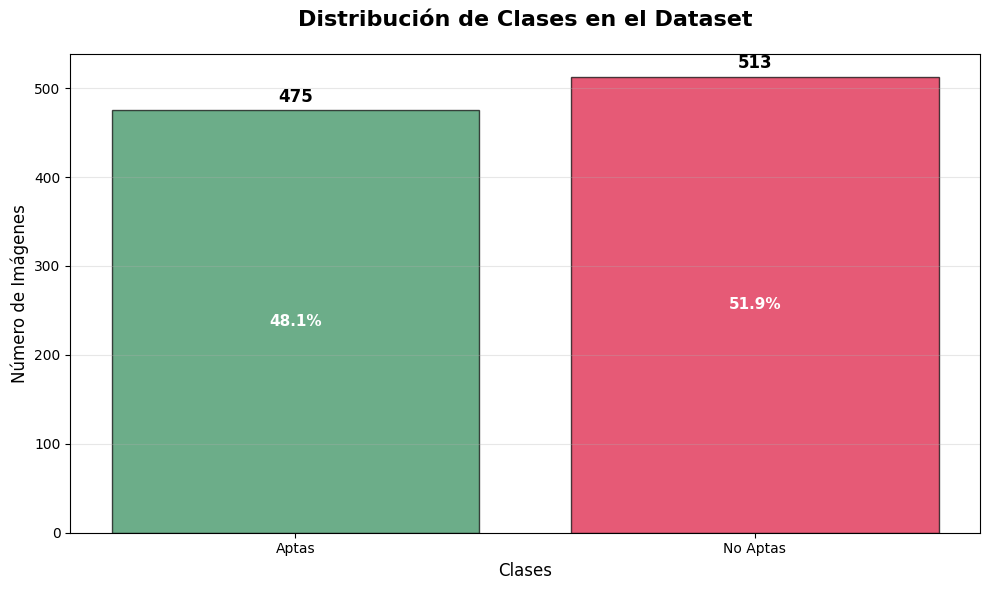


🖼️  ARCHIVOS DE MUESTRA:

   📂 Ejemplos de 'APTAS' (3 de 475):
      1. larva_20250526_145522_masked.jpg
      2. larva_20250526_145544_masked.jpg
      3. larva_20250526_145613_masked.jpg

   📂 Ejemplos de 'NO APTAS' (3 de 513):
      1. larva_20250526_145116_masked.jpg
      2. larva_20250526_145700_masked.jpg
      3. larva_20250526_145710_masked.jpg

✅ Análisis completado!
🎯 Dataset listo para entrenamiento con 988 imágenes

🔄 PASO 2: Creando división train/test...

🔄 DIVISIÓN TRAIN/TEST COMPLETADA

📚 CONJUNTO DE ENTRENAMIENTO:
   └── Aptas: 380 imágenes
   └── No Aptas: 410 imágenes
   └── Total Train: 790 imágenes

🧪 CONJUNTO DE PRUEBA:
   └── Aptas: 95 imágenes
   └── No Aptas: 103 imágenes
   └── Total Test: 198 imágenes

📊 PROPORCIONES:
   └── Train: 80.0% del total
   └── Test: 20.0% del total

⚖️  BALANCE EN TRAIN:
   └── Aptas: 48.1%
   └── No Aptas: 51.9%

⚖️  BALANCE EN TEST:
   └── Aptas: 48.0%
   └── No Aptas: 52.0%

📊 PASO 3: Visualizando división...


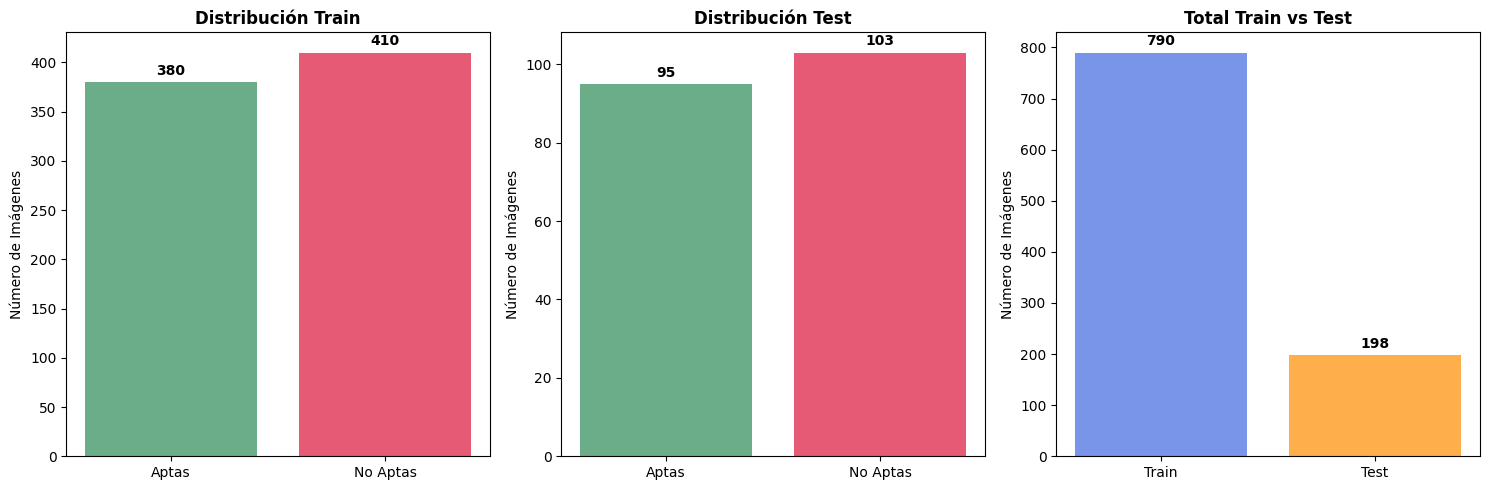


📋 INFORMACIÓN PARA DATA LOADERS:
   └── Archivos train: train_data['all_files'] (790 elementos)
   └── Labels train: train_data['labels'] (790 elementos)
   └── Archivos test: test_data['all_files'] (198 elementos)
   └── Labels test: test_data['labels'] (198 elementos)

🏷️  MAPEO DE LABELS:
   └── 'apta' = clase positiva
   └── 'no_apta' = clase negativa

💡 EJEMPLO DE USO:
   # Para acceder a los datos:
   train_files = split_data['train']['all_files']
   train_labels = split_data['train']['labels']
   test_files = split_data['test']['all_files']
   test_labels = split_data['test']['labels']

✅ ¡ANÁLISIS COMPLETO FINALIZADO!
🎯 Dataset dividido y listo para entrenar tu modelo

🚀 Variables principales disponibles:
   - split_data: contiene train/test divididos
   - original_stats: estadísticas del dataset original


In [9]:
# Configurar rutas (ajustar según tu estructura en Colab)
APTAS_PATH = '/content/drive/MyDrive/Proyecto Final de Carrera/Data-sets/Larvas/Enmascarada-Aptas'  # Ajustar ruta
NO_APTAS_PATH = '/content/drive/MyDrive/Proyecto Final de Carrera/Data-sets/Larvas/Enmascarada-No-Aptas'  # Ajustar ruta

split_data, original_stats = complete_dataset_analysis(
        aptas_path=APTAS_PATH,
        no_aptas_path=NO_APTAS_PATH,
        test_size=0.2,  # 20% para test
        random_state=42
    )

    # Opción 2: Solo análisis (sin división)
    # aptas, no_aptas, estadisticas = analyze_image_dataset(APTAS_PATH, NO_APTAS_PATH)

    # Opción 3: Análisis + división manual
    # aptas, no_aptas, stats = analyze_image_dataset(APTAS_PATH, NO_APTAS_PATH)
    # split_data = create_train_test_split(aptas, no_aptas, test_size=0.3)

print(f"\n🚀 Variables principales disponibles:")
print(f"   - split_data: contiene train/test divididos")
print(f"   - original_stats: estadísticas del dataset original")

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow import keras
import os
import gc
from tqdm import tqdm
from skimage.measure import find_contours
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense,Dropout, Reshape, BatchNormalization, LeakyReLU, Input, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import cv2
from pathlib import Path

# Parámetros del modelo
IMG_SIZE = 128

def prepare_data_from_split(split_data, img_size=128):
    """
    Prepara los datos de entrenamiento y test desde split_data.
    CAMBIO 1: Agregado data augmentation y mejor preprocesamiento
    """

    def load_and_preprocess_images(file_paths, labels):
        """Carga y preprocesa las imágenes"""
        images = []
        processed_labels = []

        print(f"🔄 Cargando {len(file_paths)} imágenes...")

        for i, (file_path, label) in enumerate(zip(file_paths, labels)):
            try:
                # Cargar imagen
                img = cv2.imread(str(file_path))
                if img is None:
                    print(f"⚠️  No se pudo cargar: {file_path}")
                    continue



                # CAMBIO: Normalización explícita a [0,1]


                images.append(img)

                # Mapear labels: 'apta' -> 1, 'no_apta' -> 0
                numeric_label = 1 if label == 'apta' else 0
                processed_labels.append(numeric_label)

                # Mostrar progreso cada 100 imágenes
                if (i + 1) % 100 == 0:
                    print(f"   Procesadas: {i + 1}/{len(file_paths)}")

            except Exception as e:
                print(f"❌ Error procesando {file_path}: {e}")
                continue

        return np.array(images), np.array(processed_labels)

    # Preparar datos de entrenamiento
    print("📚 PREPARANDO DATOS DE ENTRENAMIENTO...")
    X_train, y_train = load_and_preprocess_images(
        split_data['train']['all_files'],
        split_data['train']['labels']
    )

    # Preparar datos de test
    print("🧪 PREPARANDO DATOS DE TEST...")
    X_test, y_test = load_and_preprocess_images(
        split_data['test']['all_files'],
        split_data['test']['labels']
    )

    # Mostrar resumen
    print(f"\n✅ DATOS PREPARADOS:")
    print(f"   └── X_train shape: {X_train.shape}")
    print(f"   └── y_train shape: {y_train.shape}")
    print(f"   └── X_test shape: {X_test.shape}")
    print(f"   └── y_test shape: {y_test.shape}")

    # Mostrar distribución de labels
    print(f"\n📊 DISTRIBUCIÓN DE LABELS:")
    train_aptas = np.sum(y_train == 1)
    train_no_aptas = np.sum(y_train == 0)
    test_aptas = np.sum(y_test == 1)
    test_no_aptas = np.sum(y_test == 0)

    print(f"   TRAIN - Aptas (1): {train_aptas}, No Aptas (0): {train_no_aptas}")
    print(f"   TEST  - Aptas (1): {test_aptas}, No Aptas (0): {test_no_aptas}")

    return X_train, y_train, X_test, y_test

def create_data_generators(X_train, y_train, X_test, y_test):
    """
    CAMBIO 2: Crear generadores de datos con augmentation
    """
    # Data augmentation solo para entrenamiento
    train_datagen = ImageDataGenerator(
        rotation_range=20,           # Rotación hasta 20 grados

        horizontal_flip=True,        # Flip horizontal


        # NO agregamos más transformaciones para evitar distorsionar demasiado las imágenes médicas
    )

    # Para validación, solo normalización (ya está hecha)
    val_datagen = ImageDataGenerator()

    # Crear generadores
    train_generator = train_datagen.flow(X_train, y_train, batch_size=32, shuffle=True)
    val_generator = val_datagen.flow(X_test, y_test, batch_size=32, shuffle=False)

    print(f"✅ GENERADORES CREADOS:")
    print(f"   └── Train generator: {len(train_generator)} batches")
    print(f"   └── Validation generator: {len(val_generator)} batches")

    return train_generator, val_generator

def create_and_train_model(X_train, y_train, X_test, y_test):
    """
    Crea y entrena el modelo con mejores prácticas para evitar overfitting.
    """

    print(f"\n🏗️  CREANDO MODELO...")

    # Tu modelo exacto (sin cambios en estructura)
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])

    # CAMBIO 3: Learning rate más bajo y decay
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # Reducido de 0.001 a 0.0005
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # CAMBIO 4: Callbacks mejorados para evitar overfitting
    rlrop = ReduceLROnPlateau(
        monitor="val_loss",          # CAMBIO: monitorear val_loss en lugar de val_accuracy
        factor=0.5,
        patience=5,                  # CAMBIO: reducido de 10 a 5 para ser más agresivo
        verbose=1,
        min_lr=1e-6                  # CAMBIO: reducido de 1e-5 a 1e-6
    )

    mc = ModelCheckpoint(
        "model_cnn.h5", # Modified to save as .h5
        monitor="val_loss",          # CAMBIO: monitorear val_loss
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='min'                   # CAMBIO: modo 'min' para loss
    )

    es = EarlyStopping(
        monitor="val_loss",          # CAMBIO: monitorear val_loss
        patience=15,                 # CAMBIO: reducido de 40 a 15
        verbose=1,
        restore_best_weights=True,
        mode='min'                   # CAMBIO: modo 'min' para loss
    )

    print(f"📋 RESUMEN DEL MODELO:")
    model.summary()

    # CAMBIO 5: Usar data augmentation
    print(f"\n🔄 CREANDO GENERADORES DE DATOS CON AUGMENTATION...")
    train_generator, val_generator = create_data_generators(X_train, y_train, X_test, y_test)

    print(f"\n🚀 INICIANDO ENTRENAMIENTO CON MEJORAS ANTI-OVERFITTING...")
    print(f"   └── Epochs: 100")
    print(f"   └── Batch size: 32")
    print(f"   └── Learning rate inicial: 0.0005 (reducido)")
    print(f"   └── Data augmentation: ✅")
    print(f"   └── Early stopping más agresivo: ✅")
    print(f"   └── ReduceLR más sensible: ✅")

    # CAMBIO 6: Usar fit con generadores
    history = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=100,
        validation_data=val_generator,
        validation_steps=len(val_generator),
        callbacks=[rlrop, es, mc],
        verbose=1
    )

    print(f"\n✅ ENTRENAMIENTO COMPLETADO!")

    return model, history

def plot_training_history(history):
    """
    Crea gráficos de loss y accuracy durante el entrenamiento.
    CAMBIO 7: Mejoradas las visualizaciones para detectar overfitting
    """

    # Configurar el estilo
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Gráfico de Loss
    axes[0,0].plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0,0].plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0,0].set_title('Pérdida del Modelo', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Época')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Gráfico de Accuracy
    axes[0,1].plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0,1].plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0,1].set_title('Precisión del Modelo', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Época')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # NUEVO: Gráfico de diferencia entre train y val (detectar overfitting)
    loss_diff = np.array(history.history['loss']) - np.array(history.history['val_loss'])
    acc_diff = np.array(history.history['accuracy']) - np.array(history.history['val_accuracy'])

    axes[1,0].plot(loss_diff, 'g-', label='Loss Difference (Train - Val)', linewidth=2)
    axes[1,0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axes[1,0].set_title('Diferencia de Loss (Indicador de Overfitting)', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Época')
    axes[1,0].set_ylabel('Diferencia')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(acc_diff, 'purple', label='Accuracy Difference (Train - Val)', linewidth=2)
    axes[1,1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axes[1,1].set_title('Diferencia de Accuracy (Indicador de Overfitting)', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Época')
    axes[1,1].set_ylabel('Diferencia')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Mostrar estadísticas finales y análisis de overfitting
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    loss_gap = final_train_loss - final_val_loss
    acc_gap = final_train_acc - final_val_acc

    print(f"\n📈 RESULTADOS FINALES:")
    print(f"   └── Train Loss: {final_train_loss:.4f}")
    print(f"   └── Validation Loss: {final_val_loss:.4f}")
    print(f"   └── Train Accuracy: {final_train_acc:.4f}")
    print(f"   └── Validation Accuracy: {final_val_acc:.4f}")

    print(f"\n🔍 ANÁLISIS DE OVERFITTING:")
    print(f"   └── Gap de Loss: {loss_gap:.4f} {'(BUENO)' if abs(loss_gap) < 0.1 else '(REVISAR)' if abs(loss_gap) < 0.3 else '(OVERFITTING)'}")
    print(f"   └── Gap de Accuracy: {acc_gap:.4f} {'(BUENO)' if abs(acc_gap) < 0.05 else '(REVISAR)' if abs(acc_gap) < 0.15 else '(OVERFITTING)'}")

    if abs(loss_gap) > 0.3 or abs(acc_gap) > 0.15:
        print(f"   ⚠️  POSIBLE OVERFITTING DETECTADO")
    elif abs(loss_gap) < 0.1 and abs(acc_gap) < 0.05:
        print(f"   ✅ MODELO BIEN GENERALIZADO")
    else:
        print(f"   📊 MODELO EN RANGO ACEPTABLE")

def plot_confusion_matrix(model, X_test, y_test):
    """
    Crea y visualiza la matriz de confusión.
    (Sin cambios - función original)
    """

    print(f"\n🎯 GENERANDO PREDICCIONES PARA MATRIZ DE CONFUSIÓN...")

    # Hacer predicciones
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()

    # Crear matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Calcular métricas
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Visualizar matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Apta', 'Apta'],
                yticklabels=['No Apta', 'Apta'])
    plt.title('Matriz de Confusión', fontsize=16, fontweight='bold')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()

    # Mostrar métricas
    print(f"\n📊 MÉTRICAS DE EVALUACIÓN:")
    print(f"   └── Accuracy: {accuracy:.4f}")
    print(f"   └── Precision: {precision:.4f}")
    print(f"   └── Recall: {recall:.4f}")
    print(f"   └── F1-Score: {f1:.4f}")

    print(f"\n🔍 DETALLES DE LA MATRIZ:")
    print(f"   └── Verdaderos Negativos (TN): {tn}")
    print(f"   └── Falsos Positivos (FP): {fp}")
    print(f"   └── Falsos Negativos (FN): {fn}")
    print(f"   └── Verdaderos Positivos (TP): {tp}")

    # Reporte de clasificación detallado
    print(f"\n📋 REPORTE DE CLASIFICACIÓN:")
    class_names = ['No Apta', 'Apta']
    report = classification_report(y_test, y_pred, target_names=class_names)
    print(report)

    return cm, {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def complete_training_pipeline(split_data):
    """
    Pipeline completo de entrenamiento con mejoras anti-overfitting.
    """

    print("🎬 INICIANDO PIPELINE MEJORADO ANTI-OVERFITTING")
    print("="*60)

    # Paso 1: Preparar datos
    X_train, y_train, X_test, y_test = prepare_data_from_split(split_data)

    # Paso 2: Crear y entrenar modelo
    model, history = create_and_train_model(X_train, y_train, X_test, y_test)

    # Paso 3: Visualizar curvas de entrenamiento
    plot_training_history(history)

    # Paso 4: Matriz de confusión y métricas
    cm, metrics = plot_confusion_matrix(model, X_test, y_test)

    print(f"\n{'='*60}")
    print("🎉 ¡PIPELINE MEJORADO COMPLETADO!")
    print(f"✅ Modelo guardado como: model_cnn.h5") # Modified to save as .h5
    print(f"🛡️  Mejoras aplicadas:")
    print(f"   └── Data augmentation")
    print(f"   └── Learning rate reducido")
    print(f"   └── Early stopping más agresivo")
    print(f"   └── Mejor normalización de datos")
    print(f"   └── Monitoreo de val_loss")
    print(f"   └── Visualización de overfitting")
    print(f"{'='*60}")

    return model, history, metrics

# Ejemplo de uso principal
if __name__ == "__main__":
    # Asumiendo que ya tienes split_data del código anterior
    # split_data, original_stats = complete_dataset_analysis(...)

    # Ejecutar pipeline mejorado
    trained_model, training_history, final_metrics = complete_training_pipeline(split_data)

    print(f"\n🎯 Variables disponibles:")
    print(f"   - trained_model: modelo entrenado")
    print(f"   - training_history: historial de entrenamiento")
    print(f"   - final_metrics: métricas finales del modelo")

🎬 INICIANDO PIPELINE MEJORADO ANTI-OVERFITTING
📚 PREPARANDO DATOS DE ENTRENAMIENTO...
🔄 Cargando 790 imágenes...


KeyboardInterrupt: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import cv2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                   BatchNormalization, GlobalAveragePooling2D, Input,
                                   SeparableConv2D, DepthwiseConv2D)
from tensorflow.keras.optimizers import Adam, AdamW

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2
import cv2
from pathlib import Path
import tensorflow as tf

# Parámetros del modelo
IMG_SIZE = 128

def prepare_data_from_split(split_data, img_size=128):
    """
    Prepara los datos de entrenamiento y test desde split_data.
    CAMBIO 1: Agregado data augmentation y mejor preprocesamiento
    """

    def load_and_preprocess_images(file_paths, labels):
        """Carga y preprocesa las imágenes"""
        images = []
        processed_labels = []

        print(f"🔄 Cargando {len(file_paths)} imágenes...")

        for i, (file_path, label) in enumerate(zip(file_paths, labels)):
            try:
                # Cargar imagen
                img = cv2.imread(str(file_path))
                if img is None:
                    print(f"⚠️  No se pudo cargar: {file_path}")
                    continue

                # CAMBIO: Redimensionar usando cv2.INTER_AREA para mejor calidad
                img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)

                # CAMBIO: Normalización explícita a [0,1]
                img = img.astype(np.float32) / 255.0

                images.append(img)

                # Mapear labels: 'apta' -> 1, 'no_apta' -> 0
                numeric_label = 1 if label == 'apta' else 0
                processed_labels.append(numeric_label)

                # Mostrar progreso cada 100 imágenes
                if (i + 1) % 100 == 0:
                    print(f"   Procesadas: {i + 1}/{len(file_paths)}")

            except Exception as e:
                print(f"❌ Error procesando {file_path}: {e}")
                continue

        return np.array(images), np.array(processed_labels)

    # Preparar datos de entrenamiento
    print("📚 PREPARANDO DATOS DE ENTRENAMIENTO...")
    X_train, y_train = load_and_preprocess_images(
        split_data['train']['all_files'],
        split_data['train']['labels']
    )

    # Preparar datos de test
    print("🧪 PREPARANDO DATOS DE TEST...")
    X_test, y_test = load_and_preprocess_images(
        split_data['test']['all_files'],
        split_data['test']['labels']
    )

    # Mostrar resumen
    print(f"\n✅ DATOS PREPARADOS:")
    print(f"   └── X_train shape: {X_train.shape}")
    print(f"   └── y_train shape: {y_train.shape}")
    print(f"   └── X_test shape: {X_test.shape}")
    print(f"   └── y_test shape: {y_test.shape}")

    # Mostrar distribución de labels
    print(f"\n📊 DISTRIBUCIÓN DE LABELS:")
    train_aptas = np.sum(y_train == 1)
    train_no_aptas = np.sum(y_train == 0)
    test_aptas = np.sum(y_test == 1)
    test_no_aptas = np.sum(y_test == 0)

    print(f"   TRAIN - Aptas (1): {train_aptas}, No Aptas (0): {train_no_aptas}")
    print(f"   TEST  - Aptas (1): {test_aptas}, No Aptas (0): {test_no_aptas}")

    return X_train, y_train, X_test, y_test

def create_data_generators(X_train, y_train, X_test, y_test, rotation_type='random'):
    """
    CAMBIO 2: Crear generadores de datos con augmentation

    Args:
        rotation_type (str): 'random' para rotaciones aleatorias hasta 20°,
                           'fixed' para rotaciones fijas de 90°, 180°, 270°,
                           'both' para combinar ambos tipos
    """

    if rotation_type == 'random':
        # Rotaciones aleatorias suaves (mejor para imágenes médicas)
        train_datagen = ImageDataGenerator(
            rotation_range=20,           # Rotación hasta 20 grados
               # Desplazamiento vertical 10%
            horizontal_flip=True,        # Flip horizontal
                   # Rellenar píxeles faltantes
        )
        print(f"🔄 Usando rotaciones aleatorias (0-20°)")

    elif rotation_type == 'fixed':
        # Solo rotaciones fijas de 90° (sin otras transformaciones para mantener calidad)
        train_datagen = ImageDataGenerator(
            rotation_range=0,            # Sin rotación aleatoria
              # Reducido para compensar
            horizontal_flip=True,        # Flip horizontal

            # Las rotaciones de 90°, 180°, 270° se harán manualmente
        )
        print(f"🔄 Usando rotaciones fijas (90°, 180°, 270°)")

    elif rotation_type == 'both':
        # Combinación: rotaciones aleatorias suaves + algunas fijas
        train_datagen = ImageDataGenerator(
            rotation_range=15,           # Reducido porque también haremos rotaciones fijas
                # Reducido para compensar más augmentation
            horizontal_flip=True,        # Flip horizontal

        )
        print(f"🔄 Usando rotaciones combinadas (aleatorias + fijas)")

    else:
        raise ValueError("rotation_type debe ser 'random', 'fixed', o 'both'")

    # Para validación, solo normalización (ya está hecha)
    val_datagen = ImageDataGenerator()

    # Si usamos rotaciones fijas o combinadas, agregamos datos rotados manualmente
    if rotation_type in ['fixed', 'both']:
        X_train_augmented, y_train_augmented = add_fixed_rotations(X_train, y_train, rotation_type)
        print(f"📊 Datos aumentados con rotaciones fijas:")
        print(f"   └── Original: {X_train.shape[0]} imágenes")
        print(f"   └── Aumentado: {X_train_augmented.shape[0]} imágenes")
        X_train, y_train = X_train_augmented, y_train_augmented

    # Crear generadores
    train_generator = train_datagen.flow(X_train, y_train, batch_size=32, shuffle=True)
    val_generator = val_datagen.flow(X_test, y_test, batch_size=32, shuffle=False)

    print(f"✅ GENERADORES CREADOS:")
    print(f"   └── Train generator: {len(train_generator)} batches")
    print(f"   └── Validation generator: {len(val_generator)} batches")

    return train_generator, val_generator

def add_fixed_rotations(X_train, y_train, rotation_type='fixed'):
    """
    Agrega rotaciones fijas al dataset de entrenamiento.

    Args:
        X_train: Array de imágenes de entrenamiento
        y_train: Array de labels de entrenamiento
        rotation_type: 'fixed' para todas las rotaciones, 'both' para algunas rotaciones

    Returns:
        tuple: (X_augmented, y_augmented) con datos originales + rotados
    """

    print(f"🔄 Agregando rotaciones fijas...")

    X_augmented = [X_train.copy()]  # Empezar con datos originales
    y_augmented = [y_train.copy()]

    if rotation_type == 'fixed':
        # Todas las rotaciones definidas (incluye múltiplos de 90° y ángulos arbitrarios)
        rotations = [20, 60, 90, 120, 180, 240, 270, 300]
        rotation_names = ['20°','60°', '90°', '120°', '180°', '240°', '270°', '300°']
    elif rotation_type == 'both':
        # Solo algunas rotaciones para no saturar (múltiplos de 90° + algunos ángulos)
        rotations = [90, 120, 180, 270]
        rotation_names = ['90°', '120°', '180°', '270°']

    for angle, name in zip(rotations, rotation_names):
        print(f"   └── Aplicando rotación {name}...")

        # Diferenciar entre múltiplos de 90° y ángulos arbitrarios
        if angle % 90 == 0:
            # Para múltiplos de 90°: usar np.rot90 (más eficiente)
            k_rotations = angle // 90
            X_rotated = np.array([
                np.rot90(img, k=k_rotations, axes=(0,1))
                for img in X_train
            ])
        else:
            # Para ángulos arbitrarios: usar scipy.ndimage.rotate
            from scipy.ndimage import rotate
            X_rotated = np.array([
                rotate(img, angle, axes=(0,1), reshape=False, mode='nearest')
                for img in X_train
            ])

        X_augmented.append(X_rotated)
        y_augmented.append(y_train.copy())  # Labels siguen siendo los mismos

    # Concatenar todos los datos
    X_final = np.concatenate(X_augmented, axis=0)
    y_final = np.concatenate(y_augmented, axis=0)

    # Mezclar los datos
    indices = np.random.permutation(len(X_final))
    X_final = X_final[indices]
    y_final = y_final[indices]

    print(f"✅ Rotaciones fijas aplicadas:")
    print(f"   └── Rotaciones agregadas: {', '.join(rotation_names)}")
    print(f"   └── Datos originales: {len(X_train)}")
    print(f"   └── Datos finales: {len(X_final)}")
    print(f"   └── Factor de aumento: {len(X_final) / len(X_train):.1f}x")

    return X_final, y_final


# Versión alternativa si prefieres usar solo scipy.ndimage para todas las rotaciones
def add_fixed_rotations_scipy(X_train, y_train, rotation_type='fixed'):
    """
    Versión alternativa usando scipy.ndimage.rotate para todas las rotaciones.
    Más consistente pero potencialmente más lenta.
    """
    from scipy.ndimage import rotate

    print(f"🔄 Agregando rotaciones fijas (usando scipy)...")

    X_augmented = [X_train.copy()]  # Empezar con datos originales
    y_augmented = [y_train.copy()]

    if rotation_type == 'fixed':
        # Todas las rotaciones definidas
        rotations = [20, 60, 90, 120, 180, 240, 270, 300]
        rotation_names = ['20°','60°', '90°', '120°', '180°', '240°', '270°', '300°']
    elif rotation_type == 'both':
        # Solo algunas rotaciones para no saturar
        rotations = [90, 120, 180, 270]
        rotation_names = ['90°', '120°', '180°', '270°']

    for angle, name in zip(rotations, rotation_names):
        print(f"   └── Aplicando rotación {name}...")

        # Usar scipy.ndimage.rotate para todos los ángulos
        X_rotated = np.array([
            rotate(img, angle, axes=(0,1), reshape=False, mode='nearest')
            for img in X_train
        ])

        X_augmented.append(X_rotated)
        y_augmented.append(y_train.copy())  # Labels siguen siendo los mismos

    # Concatenar todos los datos
    X_final = np.concatenate(X_augmented, axis=0)
    y_final = np.concatenate(y_augmented, axis=0)

    # Mezclar los datos
    indices = np.random.permutation(len(X_final))
    X_final = X_final[indices]
    y_final = y_final[indices]

    print(f"✅ Rotaciones fijas aplicadas:")
    print(f"   └── Rotaciones agregadas: {', '.join(rotation_names)}")
    print(f"   └── Datos originales: {len(X_train)}")
    print(f"   └── Datos finales: {len(X_final)}")
    print(f"   └── Factor de aumento: {len(X_final) / len(X_train):.1f}x")

    return X_final, y_final


# Función de ejemplo de uso
def ejemplo_uso():
    """
    Ejemplo de cómo usar las funciones de rotación
    """
    # Suponiendo que tienes X_train y y_train
    # X_train shape: (n_samples, height, width, channels)
    # y_train shape: (n_samples,)

    # Opción 1: Todas las rotaciones (factor de aumento ~8x)
    X_aug_full, y_aug_full = add_fixed_rotations(X_train, y_train, rotation_type='fixed')

    # Opción 2: Solo algunas rotaciones (factor de aumento ~5x)
    X_aug_some, y_aug_some = add_fixed_rotations(X_train, y_train, rotation_type='both')

    # Opción 3: Usando scipy para todas (más consistente)
    X_aug_scipy, y_aug_scipy = add_fixed_rotations_scipy(X_train, y_train, rotation_type='fixed')

    return X_aug_full, y_aug_full
def create_and_train_model(X_train, y_train, X_test, y_test, rotation_type='random'):
    """
    Crea y entrena el modelo con mejores prácticas para evitar overfitting.

    Args:
        rotation_type (str): Tipo de rotaciones a usar:
            - 'random': rotaciones aleatorias hasta 20° (recomendado para imágenes médicas)
            - 'fixed': rotaciones fijas de 90°, 180°, 270° (aumenta 4x el dataset)
            - 'both': combinación de ambos (aumenta ~3x el dataset)
    """

    print(f"\n🏗️  CREANDO MODELO...")

    # Tu modelo exacto (sin cambios en estructura)
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.82),
        Dense(256, activation='relu'),
        Dropout(0.84),
        Dense(1, activation='sigmoid')
    ])

    model = Sequential([
            # Bloque 1: Extracción de características básicas
            Conv2D(32, (3, 3), activation='relu', padding='same',
                   input_shape=(IMG_SIZE, IMG_SIZE, 3)),
            BatchNormalization(),
            Conv2D(32, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(2, 2),
            Dropout(0.25),

            # Bloque 2: Características de nivel medio
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(2, 2),
            Dropout(0.25),

            # Bloque 3: Características complejas
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(2, 2),
            Dropout(0.3),

            # Bloque 4: Características de alto nivel
            Conv2D(256, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(256, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(2, 2),
            Dropout(0.4),

            # Pooling global en lugar de Flatten
            GlobalAveragePooling2D(),

            # Clasificador final más robusto
            Dense(512, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
            BatchNormalization(),
            Dropout(0.5),

            Dense(256, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
            BatchNormalization(),
            Dropout(0.3),

            Dense(1, activation='sigmoid')
        ])

    # CAMBIO 3: Learning rate más bajo y decay
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # Reducido de 0.001 a 0.0005
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # CAMBIO 4: Callbacks mejorados para evitar overfitting
    rlrop = ReduceLROnPlateau(
        monitor="val_loss",          # CAMBIO: monitorear val_loss en lugar de val_accuracy
        factor=0.5,
        patience=5,                  # CAMBIO: reducido de 10 a 5 para ser más agresivo
        verbose=1,
        min_lr=1e-6                  # CAMBIO: reducido de 1e-5 a 1e-6
    )

    mc = ModelCheckpoint(
        "model_cnn.h5", # Modified to save as .h5
        monitor="val_loss",          # CAMBIO: monitorear val_loss
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='min'                   # CAMBIO: modo 'min' para loss
    )

    es = EarlyStopping(
        monitor="val_loss",          # CAMBIO: monitorear val_loss
        patience=20,                 # CAMBIO: reducido de 40 a 15
        verbose=1,
        restore_best_weights=True,
        mode='min'                   # CAMBIO: modo 'min' para loss
    )

    print(f"📋 RESUMEN DEL MODELO:")
    model.summary()

    # CAMBIO 5: Usar data augmentation con tipo de rotación seleccionable
    print(f"\n🔄 CREANDO GENERADORES DE DATOS CON AUGMENTATION...")
    train_generator, val_generator = create_data_generators(X_train, y_train, X_test, y_test, rotation_type)

    print(f"\n🚀 INICIANDO ENTRENAMIENTO CON MEJORAS ANTI-OVERFITTING...")
    print(f"   └── Epochs: 100")
    print(f"   └── Batch size: 32")
    print(f"   └── Learning rate inicial: 0.0005 (reducido)")
    print(f"   └── Tipo de rotación: {rotation_type}")
    print(f"   └── Data augmentation: ✅")
    print(f"   └── Early stopping más agresivo: ✅")
    print(f"   └── ReduceLR más sensible: ✅")

    # CAMBIO 6: Usar fit con generadores
    history = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=150,
        validation_data=val_generator,
        validation_steps=len(val_generator),
        callbacks=[rlrop, es, mc],
        verbose=1
    )

    print(f"\n✅ ENTRENAMIENTO COMPLETADO!")

    return model, history

def plot_training_history(history):
    """
    Crea gráficos de loss y accuracy durante el entrenamiento.
    CAMBIO 7: Mejoradas las visualizaciones para detectar overfitting
    """

    # Configurar el estilo
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Gráfico de Loss
    axes[0,0].plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0,0].plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0,0].set_title('Pérdida del Modelo', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Época')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Gráfico de Accuracy
    axes[0,1].plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0,1].plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0,1].set_title('Precisión del Modelo', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Época')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # NUEVO: Gráfico de diferencia entre train y val (detectar overfitting)
    loss_diff = np.array(history.history['loss']) - np.array(history.history['val_loss'])
    acc_diff = np.array(history.history['accuracy']) - np.array(history.history['val_accuracy'])

    axes[1,0].plot(loss_diff, 'g-', label='Loss Difference (Train - Val)', linewidth=2)
    axes[1,0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axes[1,0].set_title('Diferencia de Loss (Indicador de Overfitting)', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Época')
    axes[1,0].set_ylabel('Diferencia')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(acc_diff, 'purple', label='Accuracy Difference (Train - Val)', linewidth=2)
    axes[1,1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axes[1,1].set_title('Diferencia de Accuracy (Indicador de Overfitting)', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Época')
    axes[1,1].set_ylabel('Diferencia')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Mostrar estadísticas finales y análisis de overfitting
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    loss_gap = final_train_loss - final_val_loss
    acc_gap = final_train_acc - final_val_acc

    print(f"\n📈 RESULTADOS FINALES:")
    print(f"   └── Train Loss: {final_train_loss:.4f}")
    print(f"   └── Validation Loss: {final_val_loss:.4f}")
    print(f"   └── Train Accuracy: {final_train_acc:.4f}")
    print(f"   └── Validation Accuracy: {final_val_acc:.4f}")

    print(f"\n🔍 ANÁLISIS DE OVERFITTING:")
    print(f"   └── Gap de Loss: {loss_gap:.4f} {'(BUENO)' if abs(loss_gap) < 0.1 else '(REVISAR)' if abs(loss_gap) < 0.3 else '(OVERFITTING)'}")
    print(f"   └── Gap de Accuracy: {acc_gap:.4f} {'(BUENO)' if abs(acc_gap) < 0.05 else '(REVISAR)' if abs(acc_gap) < 0.15 else '(OVERFITTING)'}")

    if abs(loss_gap) > 0.3 or abs(acc_gap) > 0.15:
        print(f"   ⚠️  POSIBLE OVERFITTING DETECTADO")
    elif abs(loss_gap) < 0.1 and abs(acc_gap) < 0.05:
        print(f"   ✅ MODELO BIEN GENERALIZADO")
    else:
        print(f"   📊 MODELO EN RANGO ACEPTABLE")

def plot_confusion_matrix(model, X_test, y_test):
    """
    Crea y visualiza la matriz de confusión.
    (Sin cambios - función original)
    """

    print(f"\n🎯 GENERANDO PREDICCIONES PARA MATRIZ DE CONFUSIÓN...")

    # Hacer predicciones
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()

    # Crear matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Calcular métricas
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Visualizar matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Apta', 'Apta'],
                yticklabels=['No Apta', 'Apta'])
    plt.title('Matriz de Confusión', fontsize=16, fontweight='bold')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()

    # Mostrar métricas
    print(f"\n📊 MÉTRICAS DE EVALUACIÓN:")
    print(f"   └── Accuracy: {accuracy:.4f}")
    print(f"   └── Precision: {precision:.4f}")
    print(f"   └── Recall: {recall:.4f}")
    print(f"   └── F1-Score: {f1:.4f}")

    print(f"\n🔍 DETALLES DE LA MATRIZ:")
    print(f"   └── Verdaderos Negativos (TN): {tn}")
    print(f"   └── Falsos Positivos (FP): {fp}")
    print(f"   └── Falsos Negativos (FN): {fn}")
    print(f"   └── Verdaderos Positivos (TP): {tp}")

    # Reporte de clasificación detallado
    print(f"\n📋 REPORTE DE CLASIFICACIÓN:")
    class_names = ['No Apta', 'Apta']
    report = classification_report(y_test, y_pred, target_names=class_names)
    print(report)

    return cm, {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def complete_training_pipeline(split_data, rotation_type='random'):
    """
    Pipeline completo de entrenamiento con mejoras anti-overfitting.

    Args:
        split_data: Datos divididos del dataset
        rotation_type (str): Tipo de rotaciones:
            - 'random': rotaciones aleatorias hasta 20° (DEFAULT - recomendado)
            - 'fixed': rotaciones fijas 90°, 180°, 270° (4x más datos)
            - 'both': combinación (3x más datos)
    """

    print("🎬 INICIANDO PIPELINE MEJORADO ANTI-OVERFITTING")
    print("="*60)
    print(f"🔄 Tipo de rotación seleccionado: {rotation_type.upper()}")

    if rotation_type == 'random':
        print("   └── Rotaciones aleatorias suaves (0-20°)")
        print("   └── Mejor para preservar características médicas")
    elif rotation_type == 'fixed':
        print("   └── Rotaciones fijas (90°, 180°, 270°)")
        print("   └── Aumenta 4x el dataset, más datos pero más memoria")
    elif rotation_type == 'both':
        print("   └── Rotaciones aleatorias + algunas fijas")
        print("   └── Aumenta ~3x el dataset, balance entre variedad y memoria")

    print("="*60)

    # Paso 1: Preparar datos
    X_train, y_train, X_test, y_test = prepare_data_from_split(split_data)

    # Paso 2: Crear y entrenar modelo
    model, history = create_and_train_model(X_train, y_train, X_test, y_test, rotation_type)

    # Paso 3: Visualizar curvas de entrenamiento
    plot_training_history(history)

    # Paso 4: Matriz de confusión y métricas
    cm, metrics = plot_confusion_matrix(model, X_test, y_test)

    print(f"\n{'='*60}")
    print("🎉 ¡PIPELINE MEJORADO COMPLETADO!")
    print(f"✅ Modelo guardado como: model_cnn.h5") # Modified to save as .h5
    print(f"🛡️  Mejoras aplicadas:")
    print(f"   └── Data augmentation con rotaciones {rotation_type}")
    print(f"   └── Learning rate reducido")
    print(f"   └── Early stopping más agresivo")
    print(f"   └── Mejor normalización de datos")
    print(f"   └── Monitoreo de val_loss")
    print(f"   └── Visualización de overfitting")
    print(f"{'='*60}")

    return model, history, metrics

# Ejemplo de uso principal
if __name__ == "__main__":
    # Asumiendo que ya tienes split_data del código anterior
    # split_data, original_stats = complete_dataset_analysis(...)

    # OPCIÓN 1: Rotaciones aleatorias (RECOMENDADO para imágenes médicas)
    print("🔄 Entrenando con rotaciones aleatorias...")
    trained_model, training_history, final_metrics = complete_training_pipeline(
        split_data, rotation_type='fixed'
    )

    # OPCIÓN 2: Solo rotaciones fijas (si tienes suficiente memoria y CPU)
    # print("🔄 Entrenando con rotaciones fijas...")
    # trained_model, training_history, final_metrics = complete_training_pipeline(
    #     split_data, rotation_type='fixed'
    # )

    # OPCIÓN 3: Combinación de ambas (balance entre variedad y recursos)
    # print("🔄 Entrenando con rotaciones combinadas...")
    # trained_model, training_history, final_metrics = complete_training_pipeline(
    #     split_data, rotation_type='both'
    # )

    print(f"\n🎯 Variables disponibles:")
    print(f"   - trained_model: modelo entrenado")
    print(f"   - training_history: historial de entrenamiento")
    print(f"   - final_metrics: métricas finales del modelo")

    print(f"\n💡 CONSEJOS PARA ELEGIR TIPO DE ROTACIÓN:")
    print(f"   📱 'random': Mejor para imágenes médicas, preserva características")
    print(f"   🔄 'fixed': Más datos, pero usa 4x más memoria y tiempo")
    print(f"   ⚖️  'both': Balance entre variedad y recursos")
    print(f"   🎯 Para dataset pequeño (<5000 imágenes): usa 'fixed' o 'both'")
    print(f"   🎯 Para dataset grande (>10000 imágenes): usa 'random'")

🔄 Entrenando con rotaciones aleatorias...
🎬 INICIANDO PIPELINE MEJORADO ANTI-OVERFITTING
🔄 Tipo de rotación seleccionado: FIXED
   └── Rotaciones fijas (90°, 180°, 270°)
   └── Aumenta 4x el dataset, más datos pero más memoria
📚 PREPARANDO DATOS DE ENTRENAMIENTO...
🔄 Cargando 790 imágenes...
   Procesadas: 100/790
   Procesadas: 200/790
   Procesadas: 300/790
   Procesadas: 400/790
   Procesadas: 500/790
   Procesadas: 600/790
   Procesadas: 700/790
🧪 PREPARANDO DATOS DE TEST...
🔄 Cargando 198 imágenes...
   Procesadas: 100/198

✅ DATOS PREPARADOS:
   └── X_train shape: (790, 128, 128, 3)
   └── y_train shape: (790,)
   └── X_test shape: (198, 128, 128, 3)
   └── y_test shape: (198,)

📊 DISTRIBUCIÓN DE LABELS:
   TRAIN - Aptas (1): 380, No Aptas (0): 410
   TEST  - Aptas (1): 95, No Aptas (0): 103

🏗️  CREANDO MODELO...
📋 RESUMEN DEL MODELO:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Par

In [ ]:
!pip install tensorflow==2.12.0

# Verificar la versión
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━

TensorFlow version: 2.18.0


🔄 Entrenando con rotaciones aleatorias...
🎬 INICIANDO PIPELINE MEJORADO ANTI-OVERFITTING
🔄 Tipo de rotación seleccionado: FIXED
   └── Rotaciones fijas (90°, 180°, 270°)
   └── Aumenta 4x el dataset, más datos pero más memoria
📚 PREPARANDO DATOS DE ENTRENAMIENTO...
🔄 Cargando 790 imágenes...
   Procesadas: 100/790
   Procesadas: 200/790
   Procesadas: 300/790
   Procesadas: 400/790
   Procesadas: 500/790
   Procesadas: 600/790
   Procesadas: 700/790
🧪 PREPARANDO DATOS DE TEST...
🔄 Cargando 198 imágenes...
   Procesadas: 100/198

✅ DATOS PREPARADOS:
   └── X_train shape: (790, 128, 128, 3)
   └── y_train shape: (790,)
   └── X_test shape: (198, 128, 128, 3)
   └── y_test shape: (198,)

📊 DISTRIBUCIÓN DE LABELS:
   TRAIN - Aptas (1): 380, No Aptas (0): 410
   TEST  - Aptas (1): 95, No Aptas (0): 103

🏗️  CREANDO MODELO...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


📋 RESUMEN DEL MODELO:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

...

223/223 ━━━━━━━━━━━━━━━━━━━━ 51s 134ms/step - accuracy: 0.5276 - loss: 1.0355 - val_accuracy: 0.5202 - val_loss: 2.3681 - learning_rate: 5.0000e-04
Epoch 2/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7472 - loss: 0.6731
Epoch 2: val_loss did not improve from 2.36812
223/223 ━━━━━━━━━━━━━━━━━━━━ 48s 51ms/step - accuracy: 0.7473 - loss: 0.6729 - val_accuracy: 0.5051 - val_loss: 5.6531 - learning_rate: 5.0000e-04
Epoch 3/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.7956 - loss: 0.5877
Epoch 3: val_loss improved from 2.36812 to 0.73751, saving model to model_cnn2.h5


223/223 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.7956 - loss: 0.5877 - val_accuracy: 0.7727 - val_loss: 0.7375 - learning_rate: 5.0000e-04
Epoch 4/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8100 - loss: 0.5687
Epoch 4: val_loss did not improve from 0.73751
223/223 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8100 - loss: 0.5688 - val_accuracy: 0.3586 - val_loss: 2.4121 - learning_rate: 5.0000e-04
Epoch 5/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.8027 - loss: 0.5706
Epoch 5: val_loss did not improve from 0.73751
223/223 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.8028 - loss: 0.5705 - val_accuracy: 0.4596 - val_loss: 1.2528 - learning_rate: 5.0000e-04
Epoch 6/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8121 - loss: 0.5496
Epoch 6: val_loss improved from 0.73751 to 0.41486, saving model to model_cnn2.h5


223/223 ━━━━━━━━━━━━━━━━━━━━ 12s 54ms/step - accuracy: 0.8121 - loss: 0.5496 - val_accuracy: 0.8939 - val_loss: 0.4149 - learning_rate: 5.0000e-04
Epoch 7/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8154 - loss: 0.5375
Epoch 7: val_loss did not improve from 0.41486
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 54ms/step - accuracy: 0.8154 - loss: 0.5375 - val_accuracy: 0.7525 - val_loss: 0.5808 - learning_rate: 5.0000e-04
Epoch 8/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8047 - loss: 0.5576
Epoch 8: val_loss did not improve from 0.41486
223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 54ms/step - accuracy: 0.8047 - loss: 0.5575 - val_accuracy: 0.5758 - val_loss: 1.0409 - learning_rate: 5.0000e-04
Epoch 9/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8178 - loss: 0.5201
Epoch 9: val_loss improved from 0.41486 to 0.37327, saving model to model_cnn2.h5


223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 55ms/step - accuracy: 0.8178 - loss: 0.5201 - val_accuracy: 0.9141 - val_loss: 0.3733 - learning_rate: 5.0000e-04
Epoch 10/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8229 - loss: 0.5111
Epoch 10: val_loss improved from 0.37327 to 0.35251, saving model to model_cnn2.h5


223/223 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.8229 - loss: 0.5111 - val_accuracy: 0.9242 - val_loss: 0.3525 - learning_rate: 5.0000e-04
Epoch 11/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8286 - loss: 0.4964
Epoch 11: val_loss did not improve from 0.35251
223/223 ━━━━━━━━━━━━━━━━━━━━ 12s 55ms/step - accuracy: 0.8286 - loss: 0.4964 - val_accuracy: 0.7071 - val_loss: 0.6797 - learning_rate: 5.0000e-04
Epoch 12/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8344 - loss: 0.4843
Epoch 12: val_loss did not improve from 0.35251
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.8343 - loss: 0.4844 - val_accuracy: 0.6465 - val_loss: 0.7985 - learning_rate: 5.0000e-04
Epoch 13/150
223/223 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.8220 - loss: 0.5091
Epoch 13: val_loss did not improve from 0.35251
223/223 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.8220 - loss: 0.5090 - val_accuracy: 0.8788 - val_loss: 0.3990 - learning_rate: 5.0000e-04
E

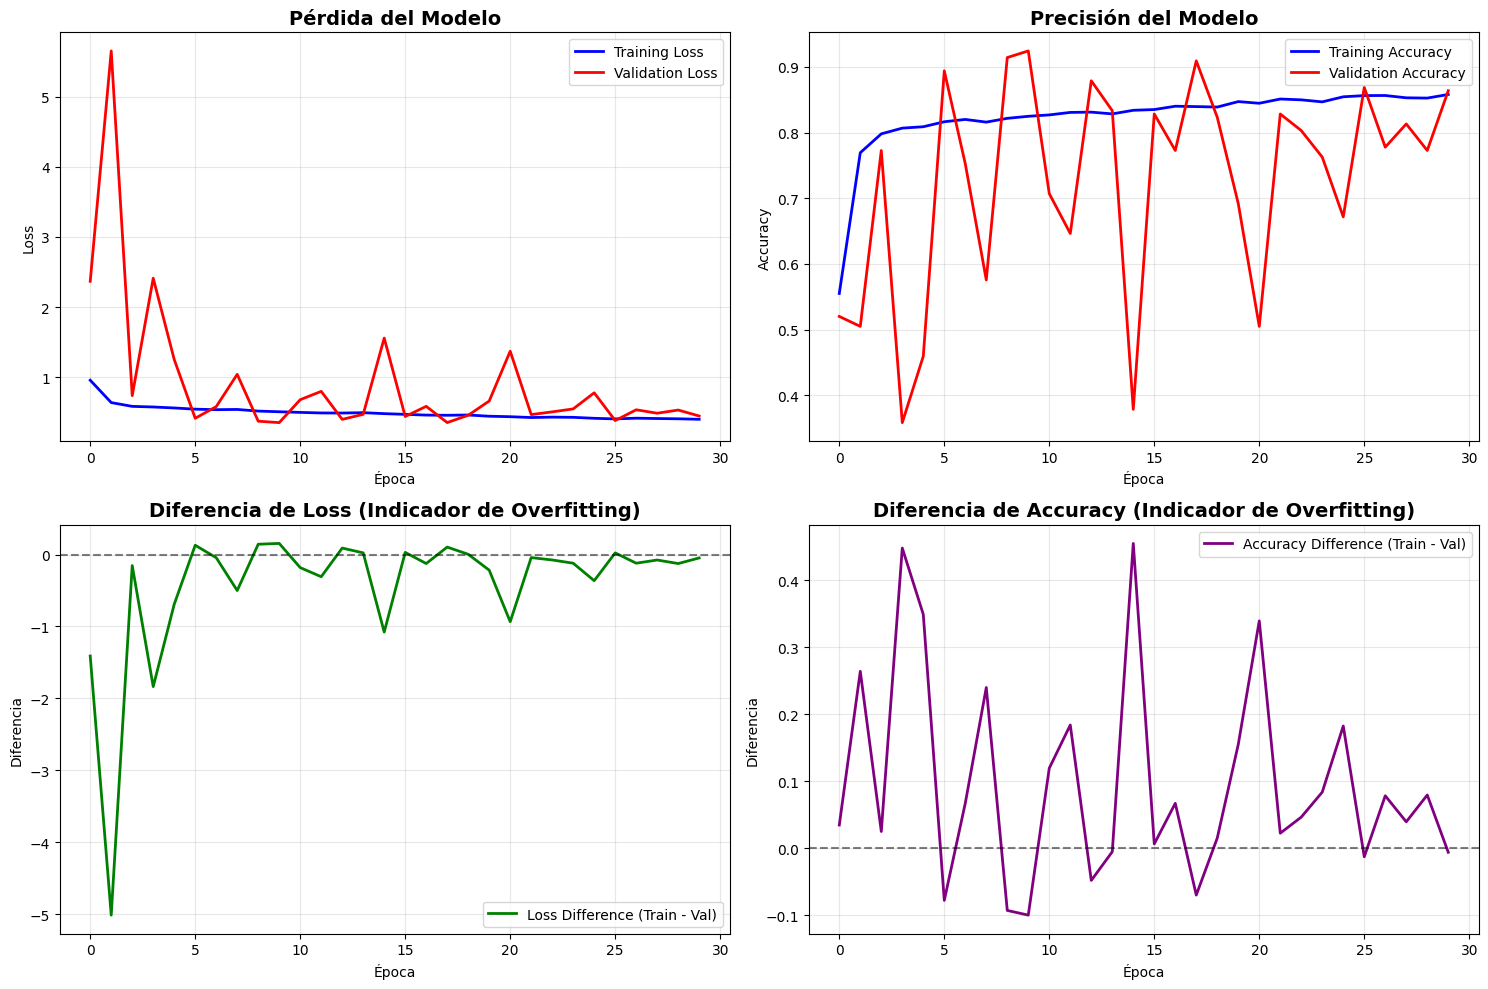


📈 RESULTADOS FINALES:
   └── Train Loss: 0.4002
   └── Validation Loss: 0.4471
   └── Train Accuracy: 0.8579
   └── Validation Accuracy: 0.8636

🔍 ANÁLISIS DE OVERFITTING:
   └── Gap de Loss: -0.0469 (BUENO)
   └── Gap de Accuracy: -0.0057 (BUENO)
   ✅ MODELO BIEN GENERALIZADO

🎯 GENERANDO PREDICCIONES PARA MATRIZ DE CONFUSIÓN...
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step


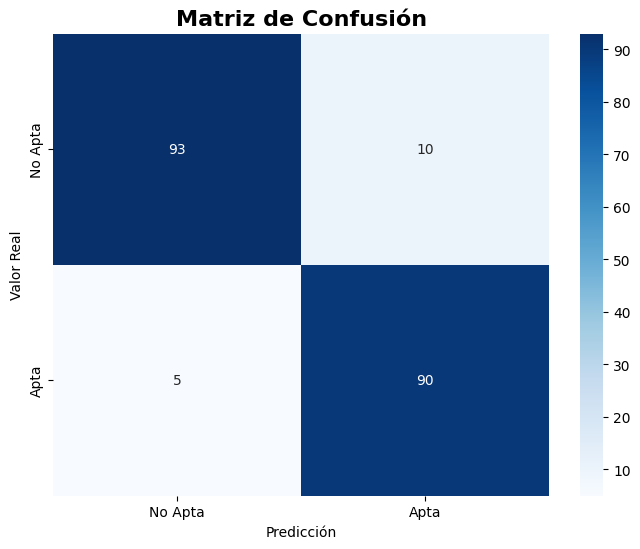


📊 MÉTRICAS DE EVALUACIÓN:
   └── Accuracy: 0.9242
   └── Precision: 0.9000
   └── Recall: 0.9474
   └── F1-Score: 0.9231

🔍 DETALLES DE LA MATRIZ:
   └── Verdaderos Negativos (TN): 93
   └── Falsos Positivos (FP): 10
   └── Falsos Negativos (FN): 5
   └── Verdaderos Positivos (TP): 90

📋 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

     No Apta       0.95      0.90      0.93       103
        Apta       0.90      0.95      0.92        95

    accuracy                           0.92       198
   macro avg       0.92      0.93      0.92       198
weighted avg       0.93      0.92      0.92       198


🎉 ¡PIPELINE MEJORADO COMPLETADO!
✅ Modelo guardado como: model_cnn.keras
🛡️  Mejoras aplicadas:
   └── Data augmentation con rotaciones fixed
   └── Learning rate reducido
   └── Early stopping más agresivo
   └── Mejor normalización de datos
   └── Monitoreo de val_loss
   └── Visualización de overfitting

🎯 Variables disponibles:
   - trained_model: mo

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
import cv2
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
                                   BatchNormalization, GlobalAveragePooling2D, Input,
                                   SeparableConv2D, DepthwiseConv2D)
from tensorflow.keras.optimizers import Adam, AdamW

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l1_l2
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2
import cv2
from pathlib import Path
import tensorflow as tf

# Parámetros del modelo
IMG_SIZE = 128

def prepare_data_from_split(split_data, img_size=128):
    """
    Prepara los datos de entrenamiento y test desde split_data.
    CAMBIO 1: Agregado data augmentation y mejor preprocesamiento
    """

    def load_and_preprocess_images(file_paths, labels):
        """Carga y preprocesa las imágenes"""
        images = []
        processed_labels = []

        print(f"🔄 Cargando {len(file_paths)} imágenes...")

        for i, (file_path, label) in enumerate(zip(file_paths, labels)):
            try:
                # Cargar imagen
                img = cv2.imread(str(file_path))
                if img is None:
                    print(f"⚠️  No se pudo cargar: {file_path}")
                    continue

                # CAMBIO: Redimensionar usando cv2.INTER_AREA para mejor calidad
                img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_AREA)

                # CAMBIO: Normalización explícita a [0,1]
                img = img.astype(np.float32) / 255.0

                images.append(img)

                # Mapear labels: 'apta' -> 1, 'no_apta' -> 0
                numeric_label = 1 if label == 'apta' else 0
                processed_labels.append(numeric_label)

                # Mostrar progreso cada 100 imágenes
                if (i + 1) % 100 == 0:
                    print(f"   Procesadas: {i + 1}/{len(file_paths)}")

            except Exception as e:
                print(f"❌ Error procesando {file_path}: {e}")
                continue

        return np.array(images), np.array(processed_labels)

    # Preparar datos de entrenamiento
    print("📚 PREPARANDO DATOS DE ENTRENAMIENTO...")
    X_train, y_train = load_and_preprocess_images(
        split_data['train']['all_files'],
        split_data['train']['labels']
    )

    # Preparar datos de test
    print("🧪 PREPARANDO DATOS DE TEST...")
    X_test, y_test = load_and_preprocess_images(
        split_data['test']['all_files'],
        split_data['test']['labels']
    )

    # Mostrar resumen
    print(f"\n✅ DATOS PREPARADOS:")
    print(f"   └── X_train shape: {X_train.shape}")
    print(f"   └── y_train shape: {y_train.shape}")
    print(f"   └── X_test shape: {X_test.shape}")
    print(f"   └── y_test shape: {y_test.shape}")

    # Mostrar distribución de labels
    print(f"\n📊 DISTRIBUCIÓN DE LABELS:")
    train_aptas = np.sum(y_train == 1)
    train_no_aptas = np.sum(y_train == 0)
    test_aptas = np.sum(y_test == 1)
    test_no_aptas = np.sum(y_test == 0)

    print(f"   TRAIN - Aptas (1): {train_aptas}, No Aptas (0): {train_no_aptas}")
    print(f"   TEST  - Aptas (1): {test_aptas}, No Aptas (0): {test_no_aptas}")

    return X_train, y_train, X_test, y_test

def create_data_generators(X_train, y_train, X_test, y_test, rotation_type='random'):
    """
    CAMBIO 2: Crear generadores de datos con augmentation

    Args:
        rotation_type (str): 'random' para rotaciones aleatorias hasta 20°,
                           'fixed' para rotaciones fijas de 90°, 180°, 270°,
                           'both' para combinar ambos tipos
    """

    if rotation_type == 'random':
        # Rotaciones aleatorias suaves (mejor para imágenes médicas)
        train_datagen = ImageDataGenerator(
            rotation_range=20,           # Rotación hasta 20 grados
               # Desplazamiento vertical 10%
            horizontal_flip=True,        # Flip horizontal
                   # Rellenar píxeles faltantes
        )
        print(f"🔄 Usando rotaciones aleatorias (0-20°)")

    elif rotation_type == 'fixed':
        # Solo rotaciones fijas de 90° (sin otras transformaciones para mantener calidad)
        train_datagen = ImageDataGenerator(
            rotation_range=0,            # Sin rotación aleatoria
              # Reducido para compensar
            horizontal_flip=True,        # Flip horizontal

            # Las rotaciones de 90°, 180°, 270° se harán manualmente
        )
        print(f"🔄 Usando rotaciones fijas (90°, 180°, 270°)")

    elif rotation_type == 'both':
        # Combinación: rotaciones aleatorias suaves + algunas fijas
        train_datagen = ImageDataGenerator(
            rotation_range=15,           # Reducido porque también haremos rotaciones fijas
                # Reducido para compensar más augmentation
            horizontal_flip=True,        # Flip horizontal

        )
        print(f"🔄 Usando rotaciones combinadas (aleatorias + fijas)")

    else:
        raise ValueError("rotation_type debe ser 'random', 'fixed', o 'both'")

    # Para validación, solo normalización (ya está hecha)
    val_datagen = ImageDataGenerator()

    # Si usamos rotaciones fijas o combinadas, agregamos datos rotados manualmente
    if rotation_type in ['fixed', 'both']:
        X_train_augmented, y_train_augmented = add_fixed_rotations(X_train, y_train, rotation_type)
        print(f"📊 Datos aumentados con rotaciones fijas:")
        print(f"   └── Original: {X_train.shape[0]} imágenes")
        print(f"   └── Aumentado: {X_train_augmented.shape[0]} imágenes")
        X_train, y_train = X_train_augmented, y_train_augmented

    # Crear generadores
    train_generator = train_datagen.flow(X_train, y_train, batch_size=32, shuffle=True)
    val_generator = val_datagen.flow(X_test, y_test, batch_size=32, shuffle=False)

    print(f"✅ GENERADORES CREADOS:")
    print(f"   └── Train generator: {len(train_generator)} batches")
    print(f"   └── Validation generator: {len(val_generator)} batches")

    return train_generator, val_generator

def add_fixed_rotations(X_train, y_train, rotation_type='fixed'):
    """
    Agrega rotaciones fijas al dataset de entrenamiento.

    Args:
        X_train: Array de imágenes de entrenamiento
        y_train: Array de labels de entrenamiento
        rotation_type: 'fixed' para todas las rotaciones, 'both' para algunas rotaciones

    Returns:
        tuple: (X_augmented, y_augmented) con datos originales + rotados
    """

    print(f"🔄 Agregando rotaciones fijas...")

    X_augmented = [X_train.copy()]  # Empezar con datos originales
    y_augmented = [y_train.copy()]

    if rotation_type == 'fixed':
        # Todas las rotaciones definidas (incluye múltiplos de 90° y ángulos arbitrarios)
        rotations = [20, 60, 90, 120, 180, 240, 270, 300]
        rotation_names = ['20°','60°', '90°', '120°', '180°', '240°', '270°', '300°']
    elif rotation_type == 'both':
        # Solo algunas rotaciones para no saturar (múltiplos de 90° + algunos ángulos)
        rotations = [90, 120, 180, 270]
        rotation_names = ['90°', '120°', '180°', '270°']

    for angle, name in zip(rotations, rotation_names):
        print(f"   └── Aplicando rotación {name}...")

        # Diferenciar entre múltiplos de 90° y ángulos arbitrarios
        if angle % 90 == 0:
            # Para múltiplos de 90°: usar np.rot90 (más eficiente)
            k_rotations = angle // 90
            X_rotated = np.array([
                np.rot90(img, k=k_rotations, axes=(0,1))
                for img in X_train
            ])
        else:
            # Para ángulos arbitrarios: usar scipy.ndimage.rotate
            from scipy.ndimage import rotate
            X_rotated = np.array([
                rotate(img, angle, axes=(0,1), reshape=False, mode='nearest')
                for img in X_train
            ])

        X_augmented.append(X_rotated)
        y_augmented.append(y_train.copy())  # Labels siguen siendo los mismos

    # Concatenar todos los datos
    X_final = np.concatenate(X_augmented, axis=0)
    y_final = np.concatenate(y_augmented, axis=0)

    # Mezclar los datos
    indices = np.random.permutation(len(X_final))
    X_final = X_final[indices]
    y_final = y_final[indices]

    print(f"✅ Rotaciones fijas aplicadas:")
    print(f"   └── Rotaciones agregadas: {', '.join(rotation_names)}")
    print(f"   └── Datos originales: {len(X_train)}")
    print(f"   └── Datos finales: {len(X_final)}")
    print(f"   └── Factor de aumento: {len(X_final) / len(X_train):.1f}x")

    return X_final, y_final


# Versión alternativa si prefieres usar solo scipy.ndimage para todas las rotaciones
def add_fixed_rotations_scipy(X_train, y_train, rotation_type='fixed'):
    """
    Versión alternativa usando scipy.ndimage.rotate para todas las rotaciones.
    Más consistente pero potencialmente más lenta.
    """
    from scipy.ndimage import rotate

    print(f"🔄 Agregando rotaciones fijas (usando scipy)...")

    X_augmented = [X_train.copy()]  # Empezar con datos originales
    y_augmented = [y_train.copy()]

    if rotation_type == 'fixed':
        # Todas las rotaciones definidas
        rotations = [20, 60, 90, 120, 180, 240, 270, 300]
        rotation_names = ['20°','60°', '90°', '120°', '180°', '240°', '270°', '300°']
    elif rotation_type == 'both':
        # Solo algunas rotaciones para no saturar
        rotations = [90, 120, 180, 270]
        rotation_names = ['90°', '120°', '180°', '270°']

    for angle, name in zip(rotations, rotation_names):
        print(f"   └── Aplicando rotación {name}...")

        # Usar scipy.ndimage.rotate para todos los ángulos
        X_rotated = np.array([
            rotate(img, angle, axes=(0,1), reshape=False, mode='nearest')
            for img in X_train
        ])

        X_augmented.append(X_rotated)
        y_augmented.append(y_train.copy())  # Labels siguen siendo los mismos

    # Concatenar todos los datos
    X_final = np.concatenate(X_augmented, axis=0)
    y_final = np.concatenate(y_augmented, axis=0)

    # Mezclar los datos
    indices = np.random.permutation(len(X_final))
    X_final = X_final[indices]
    y_final = y_final[indices]

    print(f"✅ Rotaciones fijas aplicadas:")
    print(f"   └── Rotaciones agregadas: {', '.join(rotation_names)}")
    print(f"   └── Datos originales: {len(X_train)}")
    print(f"   └── Datos finales: {len(X_final)}")
    print(f"   └── Factor de aumento: {len(X_final) / len(X_train):.1f}x")

    return X_final, y_final


# Función de ejemplo de uso
def ejemplo_uso():
    """
    Ejemplo de cómo usar las funciones de rotación
    """
    # Suponiendo que tienes X_train y y_train
    # X_train shape: (n_samples, height, width, channels)
    # y_train shape: (n_samples,)

    # Opción 1: Todas las rotaciones (factor de aumento ~8x)
    X_aug_full, y_aug_full = add_fixed_rotations(X_train, y_train, rotation_type='fixed')

    # Opción 2: Solo algunas rotaciones (factor de aumento ~5x)
    X_aug_some, y_aug_some = add_fixed_rotations(X_train, y_train, rotation_type='both')

    # Opción 3: Usando scipy para todas (más consistente)
    X_aug_scipy, y_aug_scipy = add_fixed_rotations_scipy(X_train, y_train, rotation_type='fixed')

    return X_aug_full, y_aug_full
def create_and_train_model(X_train, y_train, X_test, y_test, rotation_type='random'):
    """
    Crea y entrena el modelo con mejores prácticas para evitar overfitting.

    Args:
        rotation_type (str): Tipo de rotaciones a usar:
            - 'random': rotaciones aleatorias hasta 20° (recomendado para imágenes médicas)
            - 'fixed': rotaciones fijas de 90°, 180°, 270° (aumenta 4x el dataset)
            - 'both': combinación de ambos (aumenta ~3x el dataset)
    """

    print(f"\n🏗️  CREANDO MODELO...")

    # Tu modelo exacto (sin cambios en estructura)
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
        MaxPooling2D(2, 2),
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Conv2D(256, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.82),
        Dense(256, activation='relu'),
        Dropout(0.84),
        Dense(1, activation='sigmoid')
    ])

    model = Sequential([
            # Bloque 1: Extracción de características básicas
            Conv2D(32, (3, 3), activation='relu', padding='same',
                   input_shape=(IMG_SIZE, IMG_SIZE, 3)),
            BatchNormalization(),
            Conv2D(32, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(2, 2),
            Dropout(0.25),

            # Bloque 2: Características de nivel medio
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(64, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(2, 2),
            Dropout(0.25),

            # Bloque 3: Características complejas
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(128, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(2, 2),
            Dropout(0.3),

            # Bloque 4: Características de alto nivel
            Conv2D(256, (3, 3), activation='relu', padding='same'),
            BatchNormalization(),
            Conv2D(256, (3, 3), activation='relu', padding='same'),
            MaxPooling2D(2, 2),
            Dropout(0.4),

            # Pooling global en lugar de Flatten
            GlobalAveragePooling2D(),

            # Clasificador final más robusto
            Dense(512, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
            BatchNormalization(),
            Dropout(0.5),

            Dense(256, activation='relu', kernel_regularizer=l1_l2(l1=1e-5, l2=1e-4)),
            BatchNormalization(),
            Dropout(0.3),

            Dense(1, activation='sigmoid')
        ])

    # CAMBIO 3: Learning rate más bajo y decay
    model.compile(
        optimizer=Adam(learning_rate=0.0005),  # Reducido de 0.001 a 0.0005
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # CAMBIO 4: Callbacks mejorados para evitar overfitting
    rlrop = ReduceLROnPlateau(
        monitor="val_loss",          # CAMBIO: monitorear val_loss en lugar de val_accuracy
        factor=0.5,
        patience=5,                  # CAMBIO: reducido de 10 a 5 para ser más agresivo
        verbose=1,
        min_lr=1e-6                  # CAMBIO: reducido de 1e-5 a 1e-6
    )

    mc = ModelCheckpoint(
        "model_cnn2.h5",
        monitor="val_loss",          # CAMBIO: monitorear val_loss
        verbose=1,
        save_best_only=True,
        save_weights_only=False,
        mode='min'                   # CAMBIO: modo 'min' para loss
    )

    es = EarlyStopping(
        monitor="val_loss",          # CAMBIO: monitorear val_loss
        patience=20,                 # CAMBIO: reducido de 40 a 15
        verbose=1,
        restore_best_weights=True,
        mode='min'                   # CAMBIO: modo 'min' para loss
    )

    print(f"📋 RESUMEN DEL MODELO:")
    model.summary()

    # CAMBIO 5: Usar data augmentation con tipo de rotación seleccionable
    print(f"\n🔄 CREANDO GENERADORES DE DATOS CON AUGMENTATION...")
    train_generator, val_generator = create_data_generators(X_train, y_train, X_test, y_test, rotation_type)

    print(f"\n🚀 INICIANDO ENTRENAMIENTO CON MEJORAS ANTI-OVERFITTING...")
    print(f"   └── Epochs: 100")
    print(f"   └── Batch size: 32")
    print(f"   └── Learning rate inicial: 0.0005 (reducido)")
    print(f"   └── Tipo de rotación: {rotation_type}")
    print(f"   └── Data augmentation: ✅")
    print(f"   └── Early stopping más agresivo: ✅")
    print(f"   └── ReduceLR más sensible: ✅")

    # CAMBIO 6: Usar fit con generadores
    history = model.fit(
        train_generator,
        steps_per_epoch=len(train_generator),
        epochs=150,
        validation_data=val_generator,
        validation_steps=len(val_generator),
        callbacks=[rlrop, es, mc],
        verbose=1
    )

    print(f"\n✅ ENTRENAMIENTO COMPLETADO!")

    return model, history

def plot_training_history(history):
    """
    Crea gráficos de loss y accuracy durante el entrenamiento.
    CAMBIO 7: Mejoradas las visualizaciones para detectar overfitting
    """

    # Configurar el estilo
    plt.style.use('default')
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Gráfico de Loss
    axes[0,0].plot(history.history['loss'], 'b-', label='Training Loss', linewidth=2)
    axes[0,0].plot(history.history['val_loss'], 'r-', label='Validation Loss', linewidth=2)
    axes[0,0].set_title('Pérdida del Modelo', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Época')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)

    # Gráfico de Accuracy
    axes[0,1].plot(history.history['accuracy'], 'b-', label='Training Accuracy', linewidth=2)
    axes[0,1].plot(history.history['val_accuracy'], 'r-', label='Validation Accuracy', linewidth=2)
    axes[0,1].set_title('Precisión del Modelo', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Época')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)

    # NUEVO: Gráfico de diferencia entre train y val (detectar overfitting)
    loss_diff = np.array(history.history['loss']) - np.array(history.history['val_loss'])
    acc_diff = np.array(history.history['accuracy']) - np.array(history.history['val_accuracy'])

    axes[1,0].plot(loss_diff, 'g-', label='Loss Difference (Train - Val)', linewidth=2)
    axes[1,0].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axes[1,0].set_title('Diferencia de Loss (Indicador de Overfitting)', fontsize=14, fontweight='bold')
    axes[1,0].set_xlabel('Época')
    axes[1,0].set_ylabel('Diferencia')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(acc_diff, 'purple', label='Accuracy Difference (Train - Val)', linewidth=2)
    axes[1,1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axes[1,1].set_title('Diferencia de Accuracy (Indicador de Overfitting)', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Época')
    axes[1,1].set_ylabel('Diferencia')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Mostrar estadísticas finales y análisis de overfitting
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]

    loss_gap = final_train_loss - final_val_loss
    acc_gap = final_train_acc - final_val_acc

    print(f"\n📈 RESULTADOS FINALES:")
    print(f"   └── Train Loss: {final_train_loss:.4f}")
    print(f"   └── Validation Loss: {final_val_loss:.4f}")
    print(f"   └── Train Accuracy: {final_train_acc:.4f}")
    print(f"   └── Validation Accuracy: {final_val_acc:.4f}")

    print(f"\n🔍 ANÁLISIS DE OVERFITTING:")
    print(f"   └── Gap de Loss: {loss_gap:.4f} {'(BUENO)' if abs(loss_gap) < 0.1 else '(REVISAR)' if abs(loss_gap) < 0.3 else '(OVERFITTING)'}")
    print(f"   └── Gap de Accuracy: {acc_gap:.4f} {'(BUENO)' if abs(acc_gap) < 0.05 else '(REVISAR)' if abs(acc_gap) < 0.15 else '(OVERFITTING)'}")

    if abs(loss_gap) > 0.3 or abs(acc_gap) > 0.15:
        print(f"   ⚠️  POSIBLE OVERFITTING DETECTADO")
    elif abs(loss_gap) < 0.1 and abs(acc_gap) < 0.05:
        print(f"   ✅ MODELO BIEN GENERALIZADO")
    else:
        print(f"   📊 MODELO EN RANGO ACEPTABLE")

def plot_confusion_matrix(model, X_test, y_test):
    """
    Crea y visualiza la matriz de confusión.
    (Sin cambios - función original)
    """

    print(f"\n🎯 GENERANDO PREDICCIONES PARA MATRIZ DE CONFUSIÓN...")

    # Hacer predicciones
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba > 0.5).astype(int).flatten()

    # Crear matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Calcular métricas
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Visualizar matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Apta', 'Apta'],
                yticklabels=['No Apta', 'Apta'])
    plt.title('Matriz de Confusión', fontsize=16, fontweight='bold')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()

    # Mostrar métricas
    print(f"\n📊 MÉTRICAS DE EVALUACIÓN:")
    print(f"   └── Accuracy: {accuracy:.4f}")
    print(f"   └── Precision: {precision:.4f}")
    print(f"   └── Recall: {recall:.4f}")
    print(f"   └── F1-Score: {f1:.4f}")

    print(f"\n🔍 DETALLES DE LA MATRIZ:")
    print(f"   └── Verdaderos Negativos (TN): {tn}")
    print(f"   └── Falsos Positivos (FP): {fp}")
    print(f"   └── Falsos Negativos (FN): {fn}")
    print(f"   └── Verdaderos Positivos (TP): {tp}")

    # Reporte de clasificación detallado
    print(f"\n📋 REPORTE DE CLASIFICACIÓN:")
    class_names = ['No Apta', 'Apta']
    report = classification_report(y_test, y_pred, target_names=class_names)
    print(report)

    return cm, {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

def complete_training_pipeline(split_data, rotation_type='random'):
    """
    Pipeline completo de entrenamiento con mejoras anti-overfitting.

    Args:
        split_data: Datos divididos del dataset
        rotation_type (str): Tipo de rotaciones:
            - 'random': rotaciones aleatorias hasta 20° (DEFAULT - recomendado)
            - 'fixed': rotaciones fijas 90°, 180°, 270° (4x más datos)
            - 'both': combinación (3x más datos)
    """

    print("🎬 INICIANDO PIPELINE MEJORADO ANTI-OVERFITTING")
    print("="*60)
    print(f"🔄 Tipo de rotación seleccionado: {rotation_type.upper()}")

    if rotation_type == 'random':
        print("   └── Rotaciones aleatorias suaves (0-20°)")
        print("   └── Mejor para preservar características médicas")
    elif rotation_type == 'fixed':
        print("   └── Rotaciones fijas (90°, 180°, 270°)")
        print("   └── Aumenta 4x el dataset, más datos pero más memoria")
    elif rotation_type == 'both':
        print("   └── Rotaciones aleatorias + algunas fijas")
        print("   └── Aumenta ~3x el dataset, balance entre variedad y memoria")

    print("="*60)

    # Paso 1: Preparar datos
    X_train, y_train, X_test, y_test = prepare_data_from_split(split_data)

    # Paso 2: Crear y entrenar modelo
    model, history = create_and_train_model(X_train, y_train, X_test, y_test, rotation_type)

    # Paso 3: Visualizar curvas de entrenamiento
    plot_training_history(history)

    # Paso 4: Matriz de confusión y métricas
    cm, metrics = plot_confusion_matrix(model, X_test, y_test)

    print(f"\n{'='*60}")
    print("🎉 ¡PIPELINE MEJORADO COMPLETADO!")
    print(f"✅ Modelo guardado como: model_cnn.keras")
    print(f"🛡️  Mejoras aplicadas:")
    print(f"   └── Data augmentation con rotaciones {rotation_type}")
    print(f"   └── Learning rate reducido")
    print(f"   └── Early stopping más agresivo")
    print(f"   └── Mejor normalización de datos")
    print(f"   └── Monitoreo de val_loss")
    print(f"   └── Visualización de overfitting")
    print(f"{'='*60}")

    return model, history, metrics

# Ejemplo de uso principal
if __name__ == "__main__":
    # Asumiendo que ya tienes split_data del código anterior
    # split_data, original_stats = complete_dataset_analysis(...)

    # OPCIÓN 1: Rotaciones aleatorias (RECOMENDADO para imágenes médicas)
    print("🔄 Entrenando con rotaciones aleatorias...")
    trained_model, training_history, final_metrics = complete_training_pipeline(
        split_data, rotation_type='fixed'
    )

    # OPCIÓN 2: Solo rotaciones fijas (si tienes suficiente memoria y CPU)
    # print("🔄 Entrenando con rotaciones fijas...")
    # trained_model, training_history, final_metrics = complete_training_pipeline(
    #     split_data, rotation_type='fixed'
    # )

    # OPCIÓN 3: Combinación de ambas (balance entre variedad y recursos)
    # print("🔄 Entrenando con rotaciones combinadas...")
    # trained_model, training_history, final_metrics = complete_training_pipeline(
    #     split_data, rotation_type='both'
    # )

    print(f"\n🎯 Variables disponibles:")
    print(f"   - trained_model: modelo entrenado")
    print(f"   - training_history: historial de entrenamiento")
    print(f"   - final_metrics: métricas finales del modelo")

    print(f"\n💡 CONSEJOS PARA ELEGIR TIPO DE ROTACIÓN:")
    print(f"   📱 'random': Mejor para imágenes médicas, preserva características")
    print(f"   🔄 'fixed': Más datos, pero usa 4x más memoria y tiempo")
    print(f"   ⚖️  'both': Balance entre variedad y recursos")
    print(f"   🎯 Para dataset pequeño (<5000 imágenes): usa 'fixed' o 'both'")
    print(f"   🎯 Para dataset grande (>10000 imágenes): usa 'random'")

In [12]:
import tensorflow as tf
print(tf.__version__)

2.19.0


First, let's load the saved model.

In [13]:
import tensorflow as tf
from tensorflow import keras

# Ensure you are using the correct TensorFlow version if needed
# print(tf.__version__)

# Load the saved model
try:
    model = keras.models.load_model('model_cnn2.h5')
    print("Model loaded successfully.")
except Exception as e:
    print(f"Error loading model: {e}")
    model = None # Set model to None if loading fails

Model loaded successfully.


Now, let's convert the model to TensorFlow Lite format.

In [14]:
if model is not None:
    # Convert the model to the TensorFlow Lite format
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()

    # Save the converted model
    with open('model_cnn2.tflite', 'wb') as f:
        f.write(tflite_model)

    print("Model successfully converted to model_cnn2.tflite")
else:
    print("Model was not loaded, skipping TFLite conversion.")

Saved artifact at '/tmp/tmp1ubhs4mm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133214045021456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133214031411536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133214045023376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133214045023184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133214045014160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133214045023568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133214045023760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133214045024144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133214050088336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133214050089872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1332140500875

Let's evaluate the converted TensorFlow Lite model. We'll load the TFLite interpreter and use the test data (`X_test`) to get predictions.

In [42]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

def plot_confusion_matrix(model_or_tflite_path, X_test, y_test):
    """
    Crea y visualiza la matriz de confusión para un modelo Keras o un modelo TFLite.

    Args:
        model_or_tflite_path: Un modelo Keras entrenado o la ruta al archivo .tflite
        X_test: Datos de prueba (imágenes)
        y_test: Etiquetas reales de los datos de prueba
    """

    print(f"\n🎯 GENERANDO PREDICCIONES PARA MATRIZ DE CONFUSIÓN...")

    if isinstance(model_or_tflite_path, str) and model_or_tflite_path.endswith('.tflite'):
        # Handle TFLite model
        interpreter = tf.lite.Interpreter(model_path=model_or_tflite_path)
        interpreter.allocate_tensors()

        # Get input and output tensors
        input_details = interpreter.get_input_details()
        output_details = interpreter.get_output_details()

        y_pred_proba = []
        print(f"🚀 Realizando inferencia con TFLite en {len(X_test)} imágenes...")

        for i, image in enumerate(X_test):
            # TFLite models typically expect float32 inputs
            input_data = np.array(image, dtype=np.float32)
            # Add batch dimension
            input_data = np.expand_dims(input_data, axis=0)

            interpreter.set_tensor(input_details[0]['index'], input_data)
            interpreter.invoke()
            output_data = interpreter.get_tensor(output_details[0]['index'])

            y_pred_proba.append(output_data[0][0]) # Assuming binary classification output shape (1,)

            # Mostrar progreso cada 50 imágenes
            if (i + 1) % 50 == 0:
                print(f"   Procesadas para inferencia: {i + 1}/{len(X_test)}")


        y_pred_proba = np.array(y_pred_proba)
        y_pred = (y_pred_proba > 0.5).astype(int).flatten()

    else:
        # Handle Keras model
        model = model_or_tflite_path
        y_pred_proba = model.predict(X_test).flatten()
        y_pred = (y_pred_proba > 0.5).astype(int)


    # Crear matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Calcular métricas
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Visualizar matriz de confusión
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Apta', 'Apta'],
                yticklabels=['No Apta', 'Apta'])
    plt.title('Matriz de Confusión', fontsize=16, fontweight='bold')
    plt.xlabel('Predicción')
    plt.ylabel('Valor Real')
    plt.show()

    # Mostrar métricas
    print(f"\n📊 MÉTRICAS DE EVALUACIÓN:")
    print(f"   └── Accuracy: {accuracy:.4f}")
    print(f"   └── Precision: {precision:.4f}")
    print(f"   └── Recall: {recall:.4f}")
    print(f"   └── F1-Score: {f1:.4f}")

    print(f"\n🔍 DETALLES DE LA MATRIZ:")
    print(f"   └── Verdaderos Negativos (TN): {tn}")
    print(f"   └── Falsos Positivos (FP): {fp}")
    print(f"   └── Falsos Negativos (FN): {fn}")
    print(f"   └── Verdaderos Positivos (TP): {tp}")

    # Reporte de clasificación detallado
    print(f"\n📋 REPORTE DE CLASIFICACIÓN:")
    class_names = ['No Apta', 'Apta']
    report = classification_report(y_test, y_pred, target_names=class_names)
    print(report)

    return cm, {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [31]:
X_train, y_train, X_test, y_test = prepare_data_from_split(split_data)

📚 PREPARANDO DATOS DE ENTRENAMIENTO...
🔄 Cargando 790 imágenes...
   Procesadas: 100/790
   Procesadas: 200/790
   Procesadas: 300/790
   Procesadas: 400/790
   Procesadas: 500/790
   Procesadas: 600/790
   Procesadas: 700/790
🧪 PREPARANDO DATOS DE TEST...
🔄 Cargando 198 imágenes...
   Procesadas: 100/198

✅ DATOS PREPARADOS:
   └── X_train shape: (790, 128, 128, 3)
   └── y_train shape: (790,)
   └── X_test shape: (198, 128, 128, 3)
   └── y_test shape: (198,)

📊 DISTRIBUCIÓN DE LABELS:
   TRAIN - Aptas (1): 380, No Aptas (0): 410
   TEST  - Aptas (1): 95, No Aptas (0): 103


In [43]:
# Call the plot_confusion_matrix function with the test data
# The function uses the globally available y_pred_tflite from the TFLite evaluation step
plot_confusion_matrix(tflite_model, X_test, y_test)


🎯 GENERANDO PREDICCIONES PARA MATRIZ DE CONFUSIÓN...


AttributeError: 'bytes' object has no attribute 'predict'


🎯 GENERANDO PREDICCIONES PARA MATRIZ DE CONFUSIÓN...
🚀 Realizando inferencia con TFLite en 198 imágenes...


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


   Procesadas para inferencia: 50/198
   Procesadas para inferencia: 100/198
   Procesadas para inferencia: 150/198


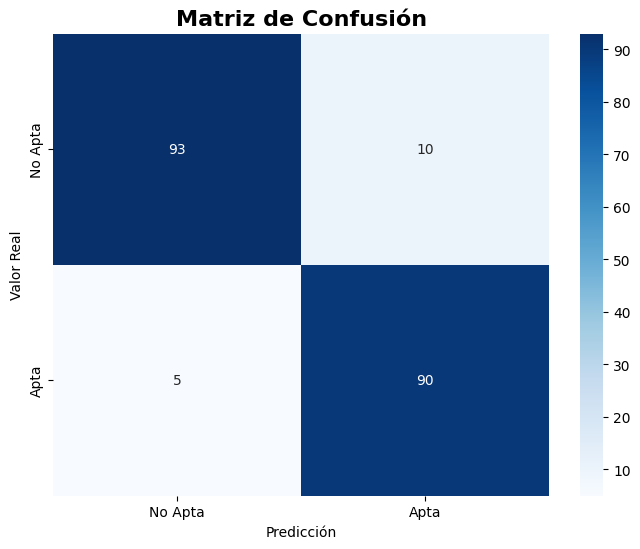


📊 MÉTRICAS DE EVALUACIÓN:
   └── Accuracy: 0.9242
   └── Precision: 0.9000
   └── Recall: 0.9474
   └── F1-Score: 0.9231

🔍 DETALLES DE LA MATRIZ:
   └── Verdaderos Negativos (TN): 93
   └── Falsos Positivos (FP): 10
   └── Falsos Negativos (FN): 5
   └── Verdaderos Positivos (TP): 90

📋 REPORTE DE CLASIFICACIÓN:
              precision    recall  f1-score   support

     No Apta       0.95      0.90      0.93       103
        Apta       0.90      0.95      0.92        95

    accuracy                           0.92       198
   macro avg       0.92      0.93      0.92       198
weighted avg       0.93      0.92      0.92       198



(array([[93, 10],
        [ 5, 90]]),
 {'accuracy': np.float64(0.9242424242424242),
  'precision': np.float64(0.9),
  'recall': np.float64(0.9473684210526315),
  'f1': np.float64(0.9230769230769231)})

In [45]:
# Call the plot_confusion_matrix function with the TFLite model path and the test data
plot_confusion_matrix('model_cnn2.tflite', X_test, y_test)